<a href="https://colab.research.google.com/github/konovalyk/Python-projects/blob/main/Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import libraries

In [ ]:
!pip install google-cloud-bigquery pandas-gbq --quiet


In [ ]:
from google.colab import auth
auth.authenticate_user()


In [ ]:

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import math
from matplotlib.colors import rgb_to_hsv, to_rgb
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, pearsonr, normaltest, f_oneway, kruskal
# import scipy.stats as stats
import matplotlib.dates as mdates


### Function

#### *format_large_numbers* – Function for formatting numbers (thousands, millions, billions)

In [ ]:
# Function for formatting numbers (thousands, millions, billions)
def format_large_numbers(x, pos):
    if x >= 1_000_000_000:
        return f'{x/1_000_000_000:.1f}B'
    elif x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.1f}K'
    return str(int(x))


#### *plot_metric_by_y* – Function to plot metrics for different categorical variables (y_labels) and returning a dict with top-n by y_label

In [ ]:


# Function to plot metrics for different categorical variables (y_labels) and returning a dict with top-n by y_label
def plot_metric_by_y(data, agg_funcs, y_labels, top_n=None, normalize=False, ascending=True):
    """
    Plots aggregated metrics for specified categorical variables.
    Automatically renames aggregated columns and sorts by the first metric.
    Optionally normalizes values to display as percentages.
    Returns top_n filtered DataFrames for each y_label.

     plot_metric_by_y(
        df_country,
        {"price": ["sum","mean",...], "ga_session_id": ["count"],...},
        ["category",...],
        top_n=10, normalize=True, ascending=False
    )

    Parameters:
    - data: DataFrame containing the dataset.
    - agg_funcs: Dictionary of metrics and corresponding aggregation functions.
    - y_labels: List of categorical columns to analyze.
    - top_n: Limits the number of categories displayed (default: None - shows all).
    - normalize: If True, values are converted to percentages.
    - ascending: Sorting order (default: True - ascending, False - descending).

    Returns:
    - Dictionary with top labels for the first metric.
    """
    if isinstance(y_labels, str):
        y_labels = [y_labels]

    if not agg_funcs:
        raise ValueError("The Aggregation functions dictionary is empty. Provide at least one metric with functions.")
    if not y_labels:
        raise ValueError("Y_labels list is empty. Provide at least one categorical variable.")
    if any(y not in data.columns for y in y_labels):
        missing_y = [y for y in y_labels if y not in data.columns]
        raise ValueError(f"Y-label(s) {missing_y} not found in data columns: {list(data.columns)}")

    # Define color palettes for different metrics
    palette_options = ["Blues", "Greens", "Purples", "Oranges"]
    metric_palette_map = {}

    for i, (metric, funcs) in enumerate(agg_funcs.items()):
        for func in funcs:
            metric_name = f"{func}_{metric}"
            metric_palette_map[metric_name] = palette_options[i % len(palette_options)]


    # Create subplot grid based on the number of y_labels and metrics
    fig, axes = plt.subplots(len(y_labels), len(metric_palette_map), figsize=(6 * len(metric_palette_map),
                                                                              4 * len(y_labels)))
    axes = np.array(axes).reshape(len(y_labels), len(metric_palette_map))

    top_label_by_first_metric = {}

    for i, y_label in enumerate(y_labels):
        # Aggregate data for the given y_label
        grouped_data = data.groupby(y_label).agg({metric: funcs for metric,
                                                  funcs in agg_funcs.items()}).reset_index()
        grouped_data.columns = [y_label] + [f"{func}_{metric}" for metric,
                                            funcs in agg_funcs.items() for func in funcs]

        # Determine the sorting column (first metric)
        sort_column = list(metric_palette_map.keys())[0]
        grouped_data = grouped_data.sort_values(by=sort_column, ascending=ascending)

        # Normalize values if required
        if normalize:
            for metric in metric_palette_map.keys():
                total_value = grouped_data[metric].sum()
                grouped_data[metric] = (grouped_data[metric] / total_value * 100).round(2)

        if top_n:
            grouped_data = grouped_data.head(top_n)

        top_label_by_first_metric[y_label] = grouped_data

        percentage_symbol = '%' if normalize else ''

        for j, metric in enumerate(metric_palette_map.keys()):
            ax = axes[i, j]
            unique_values = grouped_data[metric].nunique()
            palette = sns.color_palette(metric_palette_map[metric], n_colors=min(unique_values, len(grouped_data)))



            # Create bar plot
            bars = sns.barplot(
                data=grouped_data, x=metric, y=y_label, ax=ax, hue=metric, legend=False,
                palette=palette, errorbar=None
            )
            ax.set_title(f"{metric.replace('_', ' ').title()} by {y_label.replace('_', ' ').title()}",
                         fontweight="bold")
            ax.set_xlabel(f"{metric.replace('_', ' ').title()}{percentage_symbol}", fontweight="bold")
            ax.set_ylabel(y_label.replace('_', ' ').title(), fontweight="bold")
            ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_large_numbers))
            ax.grid(axis="x", linestyle="--", alpha=0.5)

            # Add annotations to bars
            for p in ax.patches:
                value = p.get_width()
                bar_color = to_rgb(p.get_facecolor()[:3])
                brightness = rgb_to_hsv(bar_color)[2]
                avg_rgb = np.mean(bar_color)
                text_color = 'white' if brightness < 0.5 or avg_rgb < 0.5 else 'black'

                if value < grouped_data[metric].max() * 0.5:
                    x_position = p.get_x() + value + grouped_data[metric].max() * 0.01
                    ha_alignment = 'left'
                    text_color = 'black'
                else:
                    x_position = p.get_x() + value / 2
                    ha_alignment = 'center'

                ax.annotate(f"{value:,.0f}{percentage_symbol}",
                            (x_position, p.get_y() + p.get_height() / 2.),
                            ha=ha_alignment, va='center', fontsize=10, fontweight='bold', color=text_color)

    plt.tight_layout()
    plt.show()

    return top_label_by_first_metric


#### *compare_group_means* – The function performs a statistical test to compare the means of two groups

In [ ]:
# The function performs a statistical test to compare the means of two groups
def compare_group_means(group1, group2, alpha=0.05):
    """
    Performs a statistical test to compare the means of two groups.
    - Uses Shapiro-Wilk test for normality check.
    - Applies t-test if data is normal, otherwise Mann-Whitney U test.

    Parameters:
    - group1: Numeric values of the first group.
    - group2: Numeric values of the second group.
    - alpha: Significance level (default: 0.05).

    Returns:
    - Test statistic, p-value, and interpretation.
    """
    normal1 = shapiro(group1)[1] > alpha
    normal2 = shapiro(group2)[1] > alpha

    if normal1 and normal2:
        stat, p_value = ttest_ind(group1, group2, alternative='greater')
        test_name = "T-test"
    else:
        stat, p_value = mannwhitneyu(group1, group2, alternative='greater')
        test_name = "Mann-Whitney U test"

    print(f"{test_name} results:")
    print(f"Statistic: {stat:.2f}, p-value: {p_value:.5f}")

    if p_value < alpha:
        print("Result: Statistically significant difference - The first group has a higher mean.")
    else:
        print("Result: No statistically significant difference - Cannot conclude that the first group has a higher mean.")

    return stat, p_value

#### metrics_dynamics_by_categorical_column – This function plots the trend of metrics over specified periods

In [ ]:
# Function plots the trend of metrics
def metrics_dynamics_by_categorical_column(data, date, period, metrics, categorical_columns, interval=7, top_n=None):
    """
    This function plots the trend of metrics over specified periods.
    It displays the total trend on the first row and the breakdown by categorical columns below.
    It also limits the number of lines if top_n is specified to avoid graph overload.

    Parameters:
    - data: DataFrame containing the dataset
    - date: column containing the date values
    - period: the period by which the data will be grouped ('D' for day, 'W' for week, 'M' for month, etc.)
    - metrics: List of numerical columns to be analyzed
    - categorical_columns: List of categorical columns by which the data will be segmented
    - interval: the interval between X-axis labels (default is 7 days)
    - top_n: the maximum number of categories to be used in the plot (optional)
    """
    # Convert date column to datetime format
    data[date] = pd.to_datetime(data[date])

    # Add a new column for the specified period
    data['period'] = data[date].dt.to_period(period)

    # Ensure that metrics are numeric
    for metric in metrics:
        data[metric] = pd.to_numeric(data[metric], errors='coerce')

    # Group total trend data
    total_trend = data.groupby('period')[metrics].sum().reset_index()
    total_trend['period'] = total_trend['period'].astype(str)  # Convert to string for Seaborn compatibility

    # Set up the grid size for the plots
    num_rows = len(categorical_columns) + 1  # +1 for the total trend plot
    num_cols = len(metrics)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10 * num_cols, 5 * num_rows), sharex=True)

    if num_cols == 1:
        axes = axes.reshape(-1, 1)

    # Plot the total trend (top row of plots)
    for j, metric in enumerate(metrics):
        sns.lineplot(
            data=total_trend,
            x='period',
            y=metric,
            marker='o',
            ax=axes[0, j],
            color='black',
            label='Total'
        )
        axes[0, j].set_title(f'Total Trend: {metric}', fontsize=14)
        axes[0, j].set_xlabel('Period')
        axes[0, j].set_ylabel(metric)
        axes[0, j].tick_params(axis='x', rotation=45)
        axes[0, j].grid(True)
        axes[0, j].legend()

        # Set the X-axis tick interval
        axes[0, j].xaxis.set_major_locator(mdates.DayLocator(interval=interval))

        # Format Y-axis labels with large numbers formatting
        axes[0, j].yaxis.set_major_formatter(ticker.FuncFormatter(format_large_numbers))

    # Plot dynamics for each categorical column
    for i, cat_col in enumerate(categorical_columns, start=1):
        # If top_n is specified, filter the data to include only top N categories by the metric sum
        if top_n:
            top_categories = data.groupby(cat_col)[metrics].sum().reset_index()
            top_categories = top_categories.nlargest(top_n, metrics[0])  # Use the first metric for sorting
            top_categories = top_categories[cat_col]

            # Filter data for the selected top N categories
            grouped = data[data[cat_col].isin(top_categories)].groupby(['period', cat_col])[metrics].sum().reset_index()
        else:
            grouped = data.groupby(['period', cat_col])[metrics].sum().reset_index()

        grouped['period'] = grouped['period'].astype(str)

        for j, metric in enumerate(metrics):
            sns.lineplot(
                data=grouped,
                x='period',
                y=metric,
                hue=cat_col,
                marker='o',
                ax=axes[i, j]
            )

            axes[i, j].set_title(f'Dynamics of {metric} by {cat_col}', fontsize=14)
            axes[i, j].set_xlabel('Period')
            axes[i, j].set_ylabel(metric)
            axes[i, j].tick_params(axis='x', rotation=45)
            axes[i, j].grid(True)
            axes[i, j].legend(title=cat_col, bbox_to_anchor=(1.05, 1), loc='upper left')

            # Set the X-axis tick interval
            axes[i, j].xaxis.set_major_locator(mdates.DayLocator(interval=interval))

            # Format Y-axis labels with large numbers formatting
            axes[i, j].yaxis.set_major_formatter(ticker.FuncFormatter(format_large_numbers))

    plt.tight_layout()
    plt.show()

#### analyze_trend_by – Funcion for Analyzes trends based on selected time aggregation: 'weekday', 'month', or 'year'

In [ ]:
# Funcion for Analyzes trends based on selected time aggregation: 'weekday', 'month', or 'year'
def analyze_trend_by(data, date, metrics, time_period="weekday", categorical_columns=None, top_n=None):
    """
     Analyzes trends based on selected time aggregation: 'weekday', 'month', or 'year'.

    Parameters:
    - data: DataFrame containing the dataset.
    - date: Column with date values.
    - metrics: List of metrics for trend analysis.
    - time_period: Aggregation type ('weekday', 'month', 'year').
    - categorical_columns: List of categorical columns for breakdown (optional).
    - top_n: Limits the number of unique values in categorical columns.
    """
    # Convert date column to datetime
    data[date] = pd.to_datetime(data[date])

    # Define mapping for time_period
    time_mapping = {
        "weekday": data[date].dt.day_name(),
        "month": data[date].dt.month_name(),
        "year": data[date].dt.year
    }

    if time_period not in time_mapping:
        raise ValueError("Invalid time_period. Choose from 'weekday', 'month', 'year'.")

    data["time_group"] = time_mapping[time_period]

    # Define sorting order for categorical time values
    order_mapping = {
        "weekday": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
        "month": ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"],
        "year": sorted(data["time_group"].unique())
    }

    # Filter top categories before grouping
    if categorical_columns and top_n:
        for cat_col in categorical_columns:
            top_categories = data.groupby(cat_col)[metrics].sum().nlargest(top_n, metrics[0]).index
            data = data[data[cat_col].isin(top_categories)]

    # Group data
    group_cols = ["time_group"]
    if categorical_columns:
        group_cols += categorical_columns

    df_grouped = data.groupby(group_cols)[metrics].sum().reset_index()

    # Convert time_group to categorical for proper ordering
    if time_period in ["weekday", "month"]:
        df_grouped["time_group"] = pd.Categorical(df_grouped["time_group"], categories=order_mapping[time_period], ordered=True)
        df_grouped = df_grouped.sort_values("time_group")

    # Determine subplot layout
    num_metrics = len(metrics)
    num_categoricals = len(categorical_columns) if categorical_columns else 1

    fig, axes = plt.subplots(num_metrics, num_categoricals, figsize=(6 * num_categoricals, 5 * num_metrics), sharey="row", squeeze=False)

    # Plot each metric
    for i, metric in enumerate(metrics):
        for j, cat_col in enumerate(categorical_columns if categorical_columns else [None]):
            ax = axes[i, j] if categorical_columns else axes[i, 0]

            if cat_col:
                sns.barplot(ax=ax, x="time_group", y=metric, hue=cat_col, data=df_grouped, palette="viridis", errorbar=None)
                ax.set_title(f"{metric} by {time_period.capitalize()} ({cat_col})")
            else:
                sns.barplot(ax=ax, x="time_group", y=metric, data=df_grouped, palette="viridis", errorbar=None)
                ax.set_title(f"{metric} by {time_period.capitalize()}")

            ax.tick_params(axis="x", rotation=45)
            ax.grid(True)
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_large_numbers))

    plt.tight_layout()
    plt.show()


#### _*check_distribution_and_test*_– Function Analyzes the distribution of two groups, selects an appropriate statistical test, and checks significance.

In [ ]:
# Function Analyzes the distribution of two groups, selects an appropriate statistical test, and checks significance.
def check_distribution_and_test(df, group_col, value_col, *groups, agg_func="sum"):
    """
    Analyzes the distribution of multiple groups, selects an appropriate statistical test,
    and checks significance.

    Parameters:
    - df (pd.DataFrame): The dataset containing the data.
    - group_col (str): The column name used to separate the groups.
    - value_col (str): The column name representing the values to compare.
    - *groups: The group identifiers to compare (at least 2 groups required).
    - agg_func (str): Aggregation function to apply to the metric (e.g., "sum" or "count").
    """

    if len(groups) < 2:
        raise ValueError("At least two groups must be provided.")

    # Aggregating data for each group
    grouped_data = {}
    for group in groups:
        grouped_data[group] = df[df[group_col] == group].groupby("date")[value_col].agg(agg_func).reset_index()

    # Create subplots for visualization
    fig, axes = plt.subplots(len(groups), 1, figsize=(12, 5 * len(groups)))
    if len(groups) == 1:
        axes = [axes]  # Ensure iterable if only one group

    # Plot distributions
    for ax, (group, data) in zip(axes, grouped_data.items()):
        sns.histplot(data[value_col], kde=True, bins=20, label=str(group), alpha=0.6, ax=ax)
        ax.set_title(f"Distribution of {value_col} for {group}")
        ax.set_xlabel(f"Total {value_col} per Day")
        ax.set_ylabel("Frequency")
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Normality tests (Shapiro-Wilk and D'Agostino)
    normality_results = {}
    for group, data in grouped_data.items():
        _, p_shapiro = shapiro(data[value_col])
        _, p_normaltest = normaltest(data[value_col])
        normality_results[group] = (p_shapiro, p_normaltest)

    for group, (p_shapiro, p_normaltest) in normality_results.items():
        print(f"Shapiro-Wilk Test: {group_col} {group} p-value = {p_shapiro}")
        print(f"D'Agostino's Test: {group_col} {group} p-value = {p_normaltest}")
        print(f"{group_col} {group} has {'normal' if p_shapiro >= 0.05 and p_normaltest >= 0.05 else 'non-normal'} distribution.\n")

    # Choose statistical test
    is_all_normal = all(p_shapiro >= 0.05 and p_normaltest >= 0.05 for p_shapiro, p_normaltest in normality_results.values())

    if len(groups) == 2:
        group1, group2 = groups
        data1, data2 = grouped_data[group1][value_col], grouped_data[group2][value_col]
        if is_all_normal:
            test_name = "T-test"
            stat, p_value = ttest_ind(data1, data2, equal_var=False)
        else:
            test_name = "Mann-Whitney U test"
            stat, p_value = mannwhitneyu(data1, data2, alternative="two-sided")
    else:
        data_values = [grouped_data[group][value_col] for group in groups]
        if is_all_normal:
            test_name = "ANOVA"
            stat, p_value = f_oneway(*data_values)
        else:
            test_name = "Kruskal-Wallis test"
            stat, p_value = kruskal(*data_values)

    print(f"\n📊 Applied Test: {test_name}")
    print(f"Test Statistic: {stat:.4f}")
    print(f"p-value: {p_value}")

    # Statistical significance check
    alpha = 0.05
    if p_value < alpha:
        print("❗ There is a statistically significant difference between the groups.")
    else:
        print("✅ No statistically significant difference found.")


In [ ]:
client = bigquery.Client(project="data-analytics-mate")


### SQL query for generating a dataframe

In [ ]:
query = """
select
s.date,
s.ga_session_id,
sp.continent,
sp.country,
sp.device,
sp.browser,
sp.mobile_model_name,
sp.operating_system,
sp.language,
sp.name as traffic_source,
sp.channel,
acs.account_id,
ac.is_verified,
ac.is_unsubscribed,
p.category,
p.name as product,
p.price,
p.short_description
from
`DA.session` s
join
`DA.session_params` sp
on s.ga_session_id = sp.ga_session_id
left join
`DA.order` o
on s.ga_session_id = o.ga_session_id
left join
`DA.product` p
on o.item_id = p.item_id
left join
`DA.account_session` acs
on s.ga_session_id = acs.ga_session_id
left join
`DA.account` ac
on acs.account_id = ac.id
"""

In [ ]:
query_job = client.query(query)  # Executing SQL query
results = query_job.result()  # Waiting for the request to complete

In [ ]:
df = results.to_dataframe()


### Data Quality Analysis

In [ ]:
df.head()


,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,product,price,short_description
0,2021-01-19,7268004754,(not set),(not set),desktop,Chrome,Chrome,Web,en-gb,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
1,2021-01-06,8321293308,(not set),(not set),desktop,Chrome,Chrome,Web,None,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
2,2020-11-05,4392362373,(not set),(not set),desktop,Chrome,Chrome,Web,None,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None
3,2020-12-09,140108698,(not set),(not set),desktop,Chrome,Safari,Web,en-us,(direct),Direct,<NA>,<NA>,<NA>,None,None,NaN,None
4,2020-11-10,8351127264,(not set),(not set),mobile,Safari,iPhone,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,None,None,NaN,None


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  product            33538 non-null   object 
 16  pr

In [ ]:
print(df['is_unsubscribed'].unique())
print(df['is_verified'].unique())


<IntegerArray>
[<NA>, 0, 1]
Length: 3, dtype: Int64
<IntegerArray>
[<NA>, 1, 0]
Length: 3, dtype: Int64


In [ ]:
# checking for duplicates
print(df.duplicated().sum())

0


In [ ]:
df.describe()

,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
std,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775
min,1205.0,636133.0,0.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,0.0,170.000000
50%,4988476074.0,658952.0,1.0,0.0,445.000000
75%,7491286508.0,670414.0,1.0,0.0,1195.000000
max,9999997129.0,681962.0,1.0,1.0,9585.000000


In [ ]:

print(f"Number of unique sessions: {df['ga_session_id'].nunique()}")
print(f"Unique language:{df['language'].unique()}")
date_interval = max(df['date']) - min(df['date'])
print(f"Start Date: {min(df['date'])}\nFinish Date: {max(df['date'])}\n Time period: {date_interval}")

Number of unique sessions: 349545
Unique language:['en-gb' None 'en-us' 'en-ca' 'en' 'zh' 'de' 'es-es' 'fr' 'ko']
Start Date: 2020-11-01
Finish Date: 2021-01-31
 Time period: 91 days, 0:00:00


### Data Description
* The dataset has 349,545 rows in 18 columns.
* 1 column *date* has a non-standard date format dbdate, so we will change the format to datetime64.
* 4 columns *ga_session_id*, *account_id*, *is_verified*, *is_unsubscribed* have the type Int64.
** The column *ga_session_id* has 10-digit numbers. We will leave it in the format Int64.
** The column *account_id* has 6-digit numbers. We will replace NaN with "0" and change the format to Int32.
** The columns *is_verified*, *is_unsubscribed* have the values ​​"1" - True, "0" - False, "NA" - no data. We will change the format to boolean to preserve the logic (True and False only for registered users).
* The column *price* has the type float64, we will change it to float32.
* Columns: *continent*, *country*, *device*, *browser*, *mobile_model_name*, *operating_system*, *language*, *traffic_source*, *channel*, *category*, *product* are categorical, have the type object and contain data corresponding to the column name.
* Column *short_description* has the type object and contains a short description of the product.
* In the column *language* are 235279 records. The presence of missing values ​​is due to the lack of data on the user's language.
* In the columns: *account_id*, *is_verified*, *is_unsubscribed* are 27945 records. The presence of missing values ​​is due to the fact that this information is relevant only for registered users.
* There are 33,538 records in the columns *category*, *product*, *price*, *short_description*. Missing values ​​indicate that this information is relevant for sessions with an order.
* Number of unique sessions: 349,545
* Number of sessions with orders: 33,538
* Time period: 87 days, from 2020-11-01 to 2021-01-27.
#### Опис даних
* В датасеті 349,545 рядків в 18 стовпцях.
* 1 стовпець *date* має нестандартний формат дати dbdate, тому змінемо формат datetime64.
* 4 стовпці *ga_session_id*, *account_id*, *is_verified*, *is_unsubscribed* мають тип Int64.
** Стовпець *ga_session_id* має 10-ти значні записи. Залишимо в форматі Int64.
**  Стовпець *account_id* має 6-ти значні записи. Замінимо NaN на "0" та змінимо формат на Int32.
** Стовпці *is_verified*, *is_unsubscribed* мають значення "1" - True, "0" - False, "NA" - немає даних. Змінимо формат на boolean для збереження логіки (True та False тільки для зареєстрованих користувачів).
* Стовпець *price* має тип float64 змінимо на float32.
* Стовпці: *continent*, *country*, *device*, *browser*, *mobile_model_name*, *operating_system*, *language*, *traffic_source*, *channel*, *category*, *product* категоріальні, мають тип object та містять дані відповідні до назви стовпця.
* Стовпець *short_description* має тип object містить короткий опис товару.
* В стовпці *language* 235279 запис. Наявність пропущених значень повʼязана з відсутністю даних про мову користувача.
* В стовпцях: *account_id*, *is_verified*, *is_unsubscribed* 27945 запис. Наявність пропущених значень повʼязана з тим, що ця інформація актуальна лише для зареєстрованих користувачів.
* В стовпцях *category*, *product*, *price*, *short_description* 33,538 записів. Пропущені значення свідчать про те що ця інформація актуальна для сесій з замовленням.
* Кількість унікальних сесій 349,545
* Кількість сесій з замовленнями 33,538
* Період часу 87 днів, від 2020-11-01 до 2021-01-27.





### Changing data types to correct ones, and to optimize memory usage.
### Зміна типів даних на коректні, та для оптимізації використання памʼяті.

In [ ]:
# We change the data type to optimize memory usage, and check the optimization.

# Reserved memory MB Before
memory_before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Before:{memory_before} MB")

df["date"] = pd.to_datetime(df["date"])
df["account_id"] = df["account_id"].fillna(0).astype("int32")
df['is_unsubscribed'] = df['is_unsubscribed'].astype("boolean")
df['is_verified'] = df['is_verified'].astype("boolean")
df["price"] = df["price"].astype("float32")

# Reserved memory MB After
memory_after = df.memory_usage(deep=True).sum() / 1024**2
print(f"After: {memory_after} MB")
memory_optimized = memory_before - memory_after
menory_optimized_percent = (memory_after / memory_before - 1) * 100
print(f"Optimized memory: {memory_optimized:.4f} MB {menory_optimized_percent:.2f} % of initial ")

Before:234.6006326675415 MB
After: 226.93353462219238 MB
Optimized memory: 7.6671 MB -3.27 % of initial 


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   date               349545 non-null  datetime64[ns]
 1   ga_session_id      349545 non-null  Int64         
 2   continent          349545 non-null  object        
 3   country            349545 non-null  object        
 4   device             349545 non-null  object        
 5   browser            349545 non-null  object        
 6   mobile_model_name  349545 non-null  object        
 7   operating_system   349545 non-null  object        
 8   language           235279 non-null  object        
 9   traffic_source     349545 non-null  object        
 10  channel            349545 non-null  object        
 11  account_id         349545 non-null  int32         
 12  is_verified        27945 non-null   boolean       
 13  is_unsubscribed    27945 non-null   boolean 

### Visualization and Analysis
### Візуалізація та Аналіз

#### General metrics
#### Загальні метрики

In [ ]:
# Total count session
total_count_session = df['ga_session_id'].nunique()
print(f"Total count session: {total_count_session:,.0f}")

# Total sales
total_sales = df['price'].sum()
print(f"Total Sales: {total_sales:,.0f} $")

# Total number of orders
total_order_cnt = df['price'].count()
print(f"Total Number of Orders: {total_order_cnt:,}")

# Average Selling Price
ASP = total_sales / total_order_cnt
print(f"Average Selling Price: {ASP:.2f} $\n")


Total count session: 349,545
Total Sales: 31,971,726 $
Total Number of Orders: 33,538
Average Selling Price: 953.30 $



#### Visualization and Analysis of Sales VS Popularity
#### Візуалізація та Аналіз продажів VS популярність

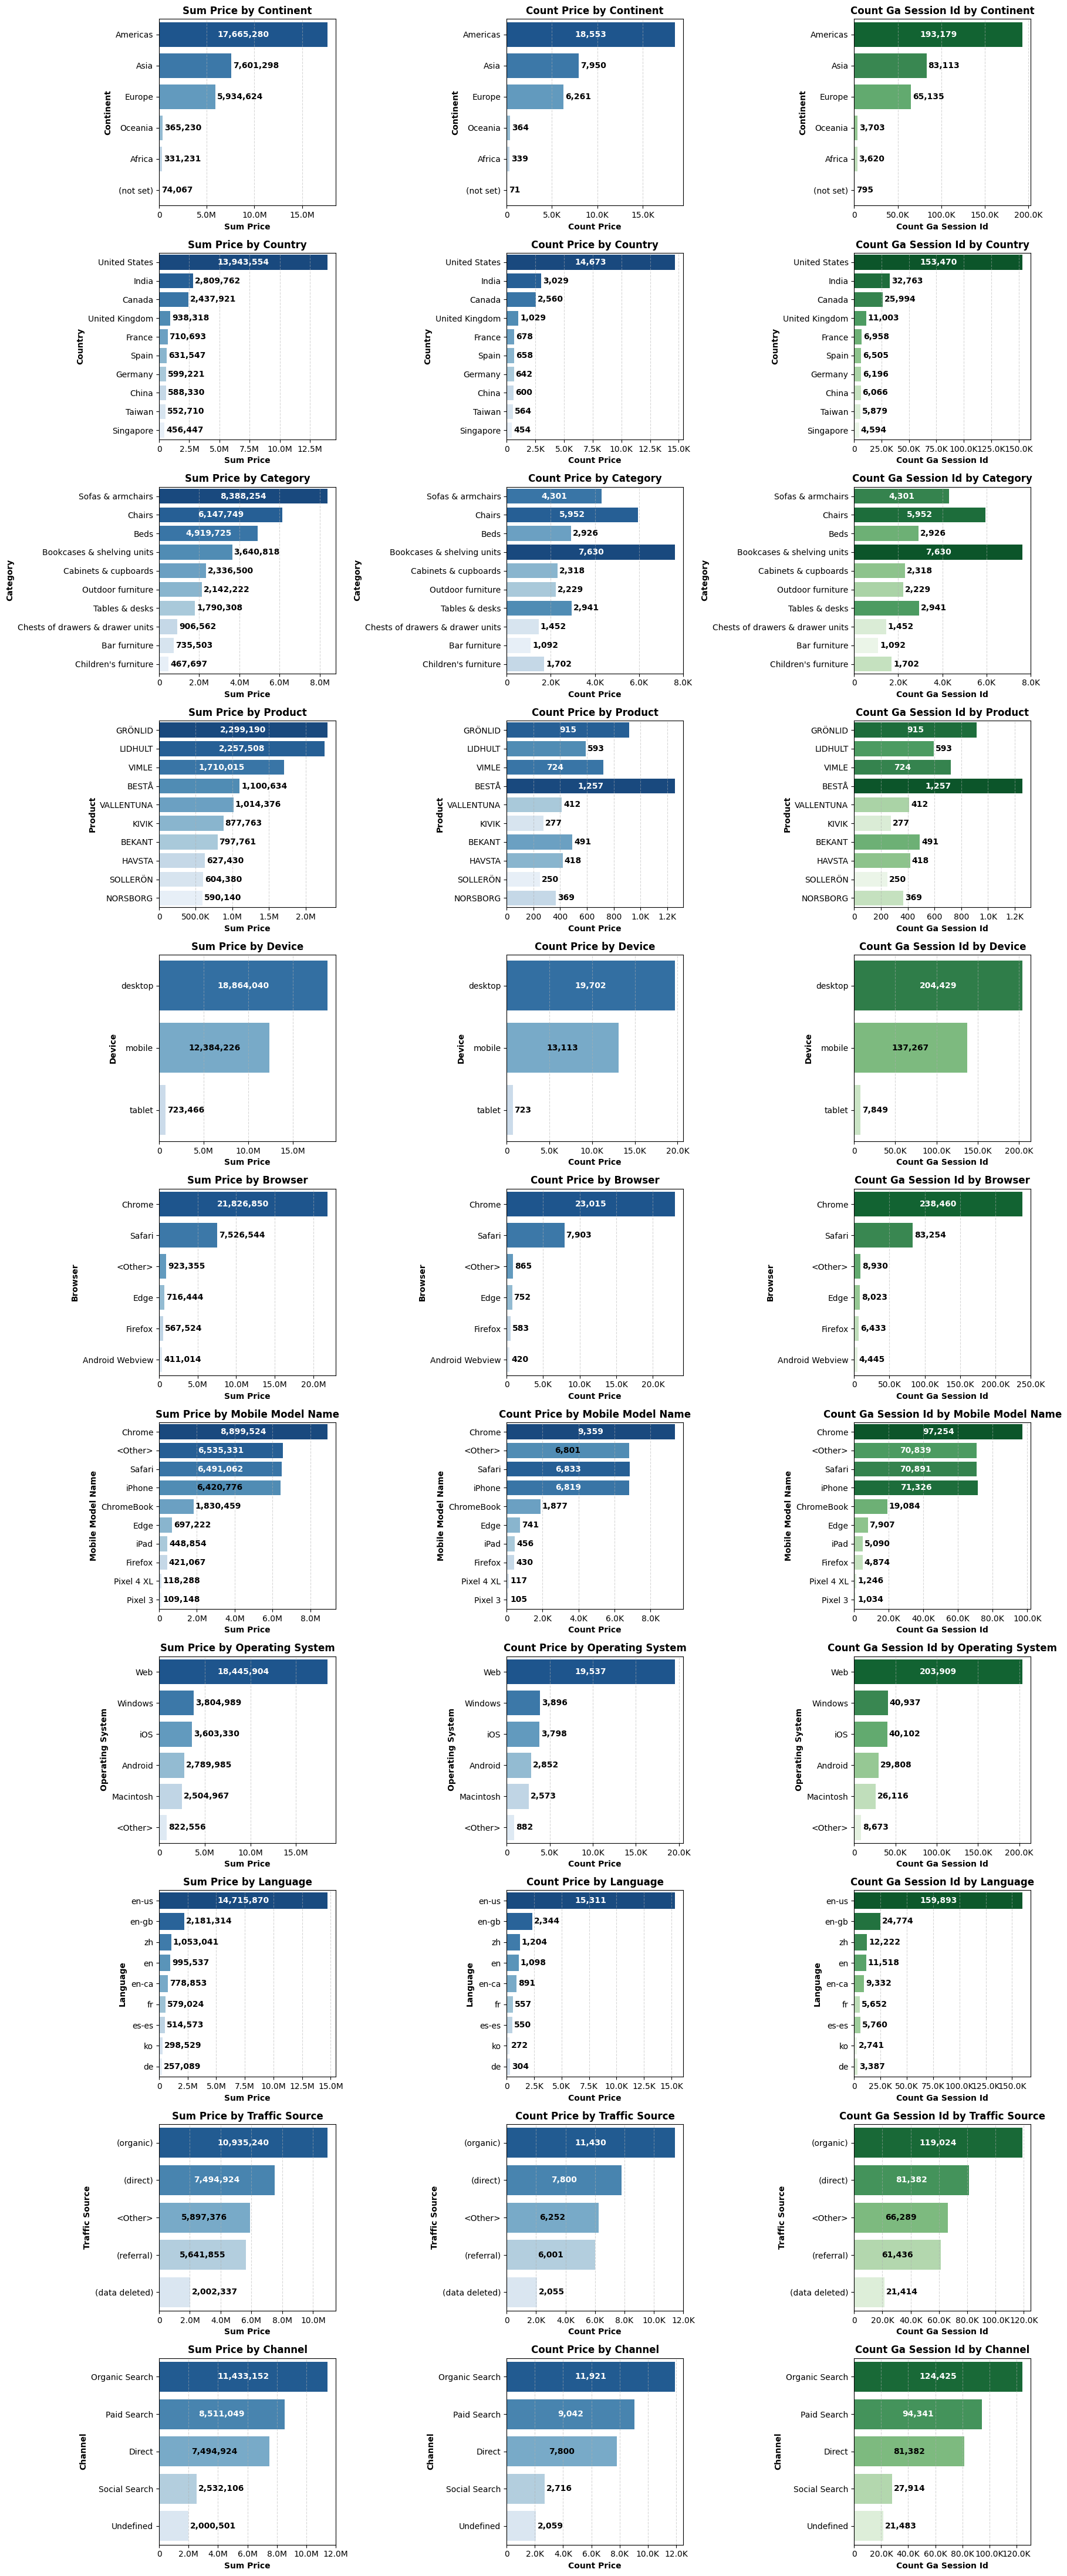

In [ ]:
#
top_data = plot_metric_by_y(df,
                            agg_funcs={"price": ["sum", "count"],
                                       "ga_session_id": ["count"]},
                            y_labels=["continent",
                                      "country",
                                      "category",
                                      "product",
                                      "device",
                                      "browser",
                                      "mobile_model_name",
                                      "operating_system",
                                      "language",
                                      "traffic_source",
                                      "channel"],
                            top_n=10,
                            ascending=False)

#### Description of diagrams
#### Опис діаграм



In [ ]:
top_3_continents = top_data["continent"].iloc[:3].continent.to_list()
print(f'TOP-3 Continents by Sales: {", ".join(top_3_continents)}')

top_5_countries = top_data["country"].iloc[:5].country.to_list()
print(f'TOP-5 Countries by Sales: {", ".join(top_5_countries)}')

top_10_categories = top_data["category"].iloc[:10].category.to_list()
print(f'TOP-10 Categories by Sales: {", ".join(top_10_categories)}')





TOP-3 Continents by Sales: Americas, Asia, Europe
TOP-5 Countries by Sales: United States, India, Canada, United Kingdom, France
TOP-10 Categories by Sales: Sofas & armchairs, Chairs, Beds, Bookcases & shelving units, Cabinets & cupboards, Outdoor furniture, Tables & desks, Chests of drawers & drawer units, Bar furniture, Children's furniture


It is worth paying attention to the categories:
* Sofas & armchairs is the first in the top in terms of profitability, the third in terms of popularity. This indicates a high margin. It is necessary to analyze the possibility of increasing popularity. Develop a hypothesis and test it. High margin usually allows you to apply discounts and promotions.
* Bookcases & shelving units is the most popular category, in 4th place in terms of profitability. This indicates a low margin. It is necessary to analyze the pricing policy in this category. Perhaps an increase in price will lead to an increase in profit.

Варто звернути увагу на категорії:
* Sofas & armchairs перша в топі за прибутковістю, третя за популярністю. Це свідчить про високу маржинальність. Потрібно проаналізувати можливість збільшення популярності. Розробити гіпотезу та перевірити її. Висока маржинальність зазвичай дозволяє застосувати знижки та акції.
* Bookcases & shelving units найпопулярніша категорія, на 4 місці за прибутковістю. Це свідчить про низьку маржинальність. Потрібно проаналізувати цінову політику в цій категорії. Можливо збільшення ціни приведе до росту прибутку.


#### Visualization and Analysis by Category
#### Візуалізація та Аналіз за Категоріями


Analyzing Total trends


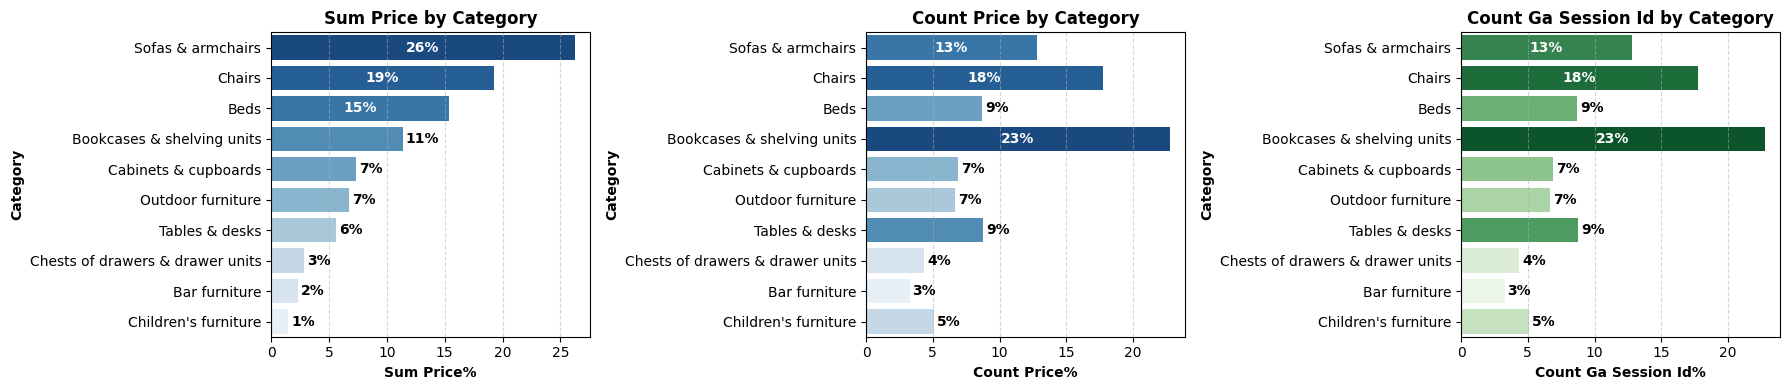


Analyzing trends for Americas


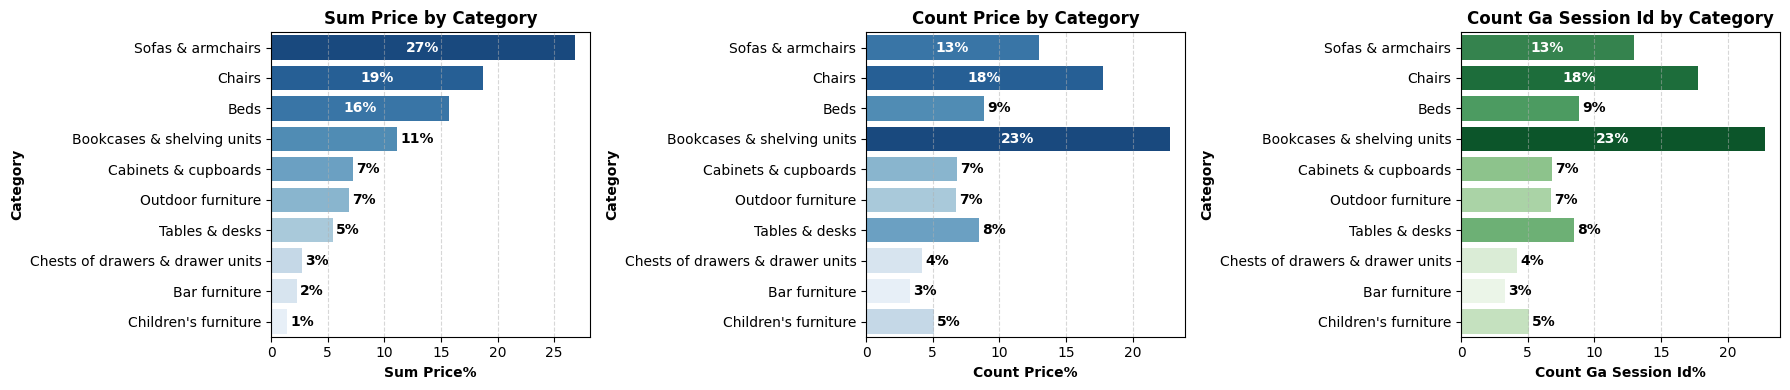


Analyzing trends for Asia


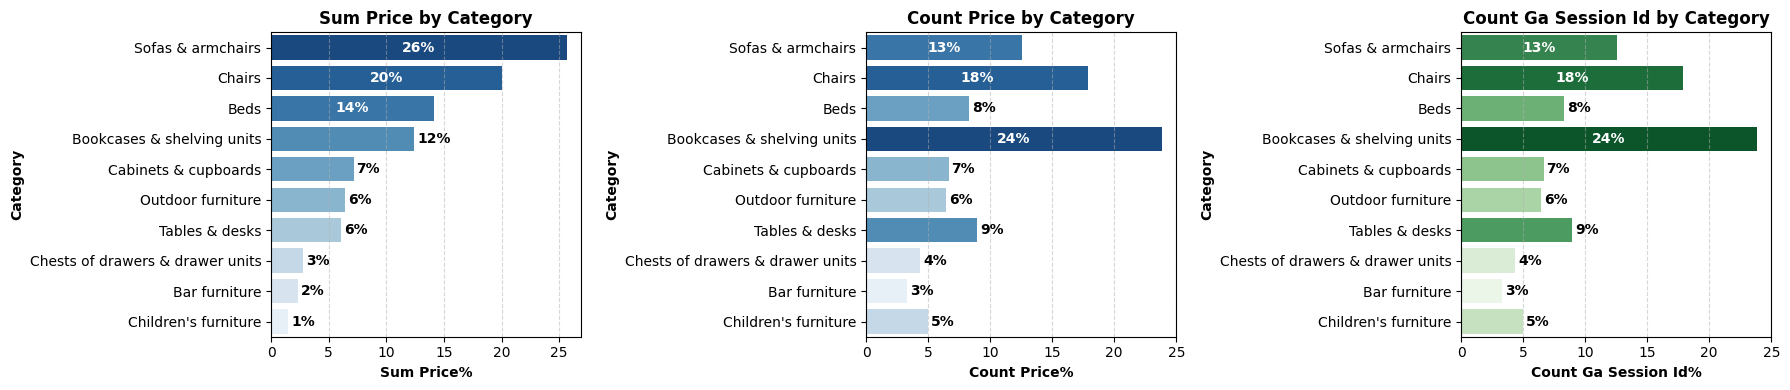


Analyzing trends for Europe


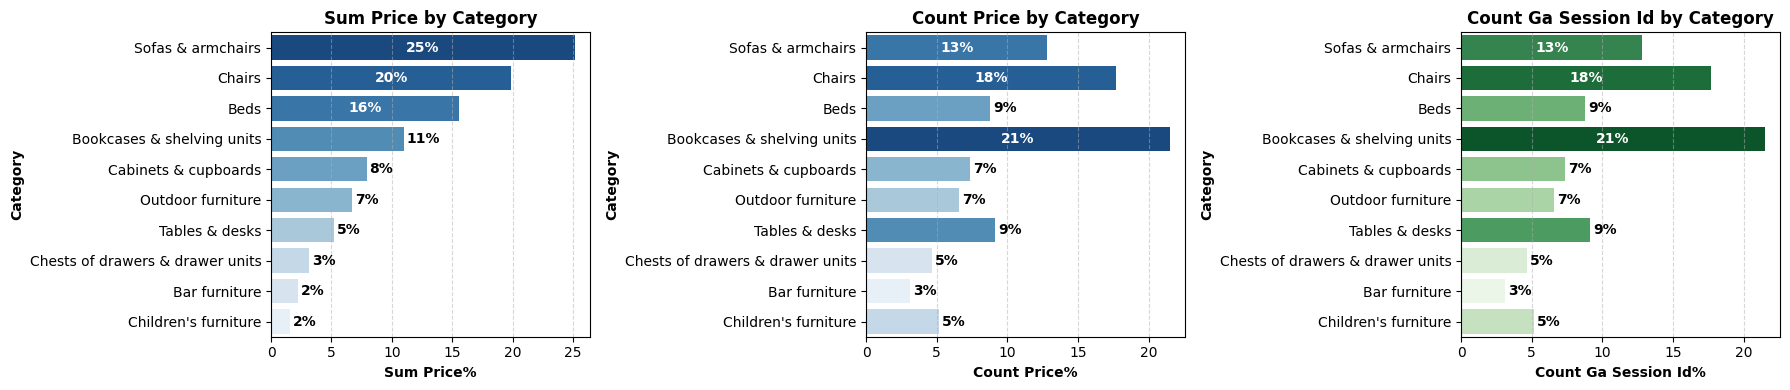


Analyzing trends for United States


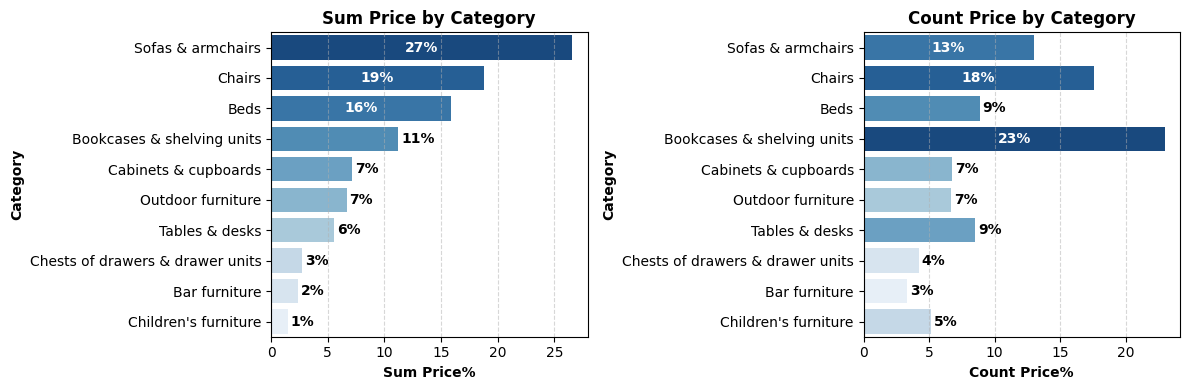


Analyzing trends for India


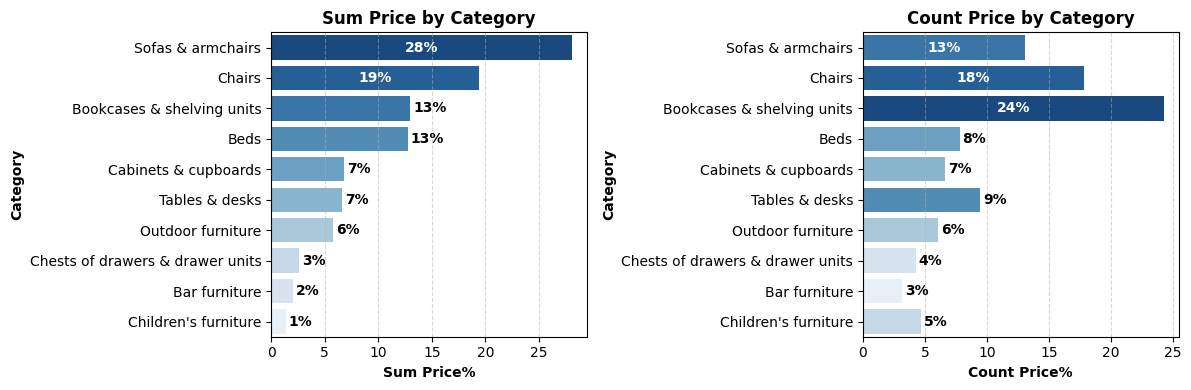


Analyzing trends for Canada


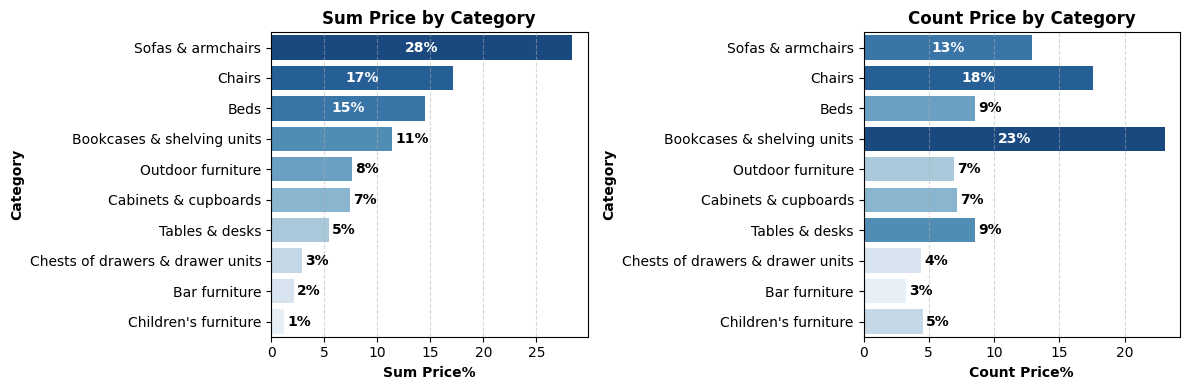


Analyzing trends for United Kingdom


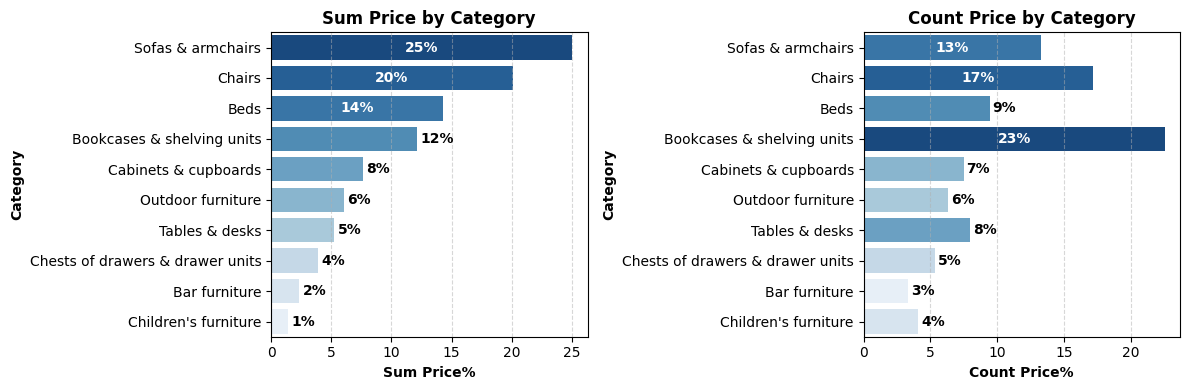


Analyzing trends for France


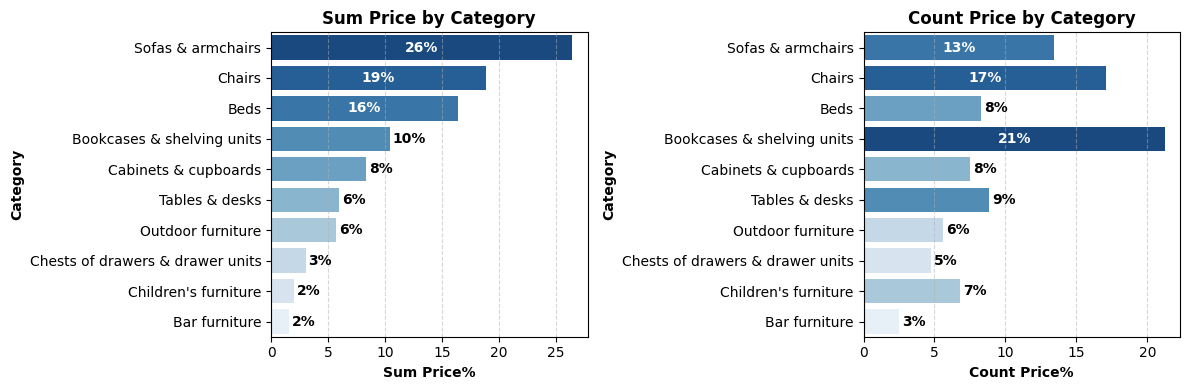

In [ ]:
# Building general trends for all data
print(f"\nAnalyzing Total trends")
plot_metric_by_y(df, {"price": ["sum", "count"], "ga_session_id": ["count"]}, ["category"],
                 top_n=10, normalize=True, ascending=False)

#Building trends for each top continents
for continent in top_3_continents:
    print(f"\nAnalyzing trends for {continent}")

    df_continent = df[df["continent"] == continent]  # Filter data for continent

    # Building charts by categories
    plot_metric_by_y(
        df_continent,
        {"price": ["sum", "count"], "ga_session_id": ["count"]},
        ["category"],
        top_n=10, normalize=True, ascending=False
    )

# Building trends for each top countries
for  country in top_5_countries:
    print(f"\nAnalyzing trends for {country}")

    df_country = df[df["country"] == country]  # Filter data for country

    # Building charts by categories
    plot_metric_by_y(
        df_country,
        {"price": ["sum", "count"]},
        ["category"],
        top_n=10, normalize=True, ascending=False
    )



The same trend across categories persists for Top Continents and Top Countries.

Така сама тенденція по категоріях зберігається для Топ континентів та Топ країн.

#### Sales Analysis in percentages by: device, mobile_model_name, traffic_source
#### Аналіз продажів у відсотках в розрізі: device, mobile_model_name, traffic_source

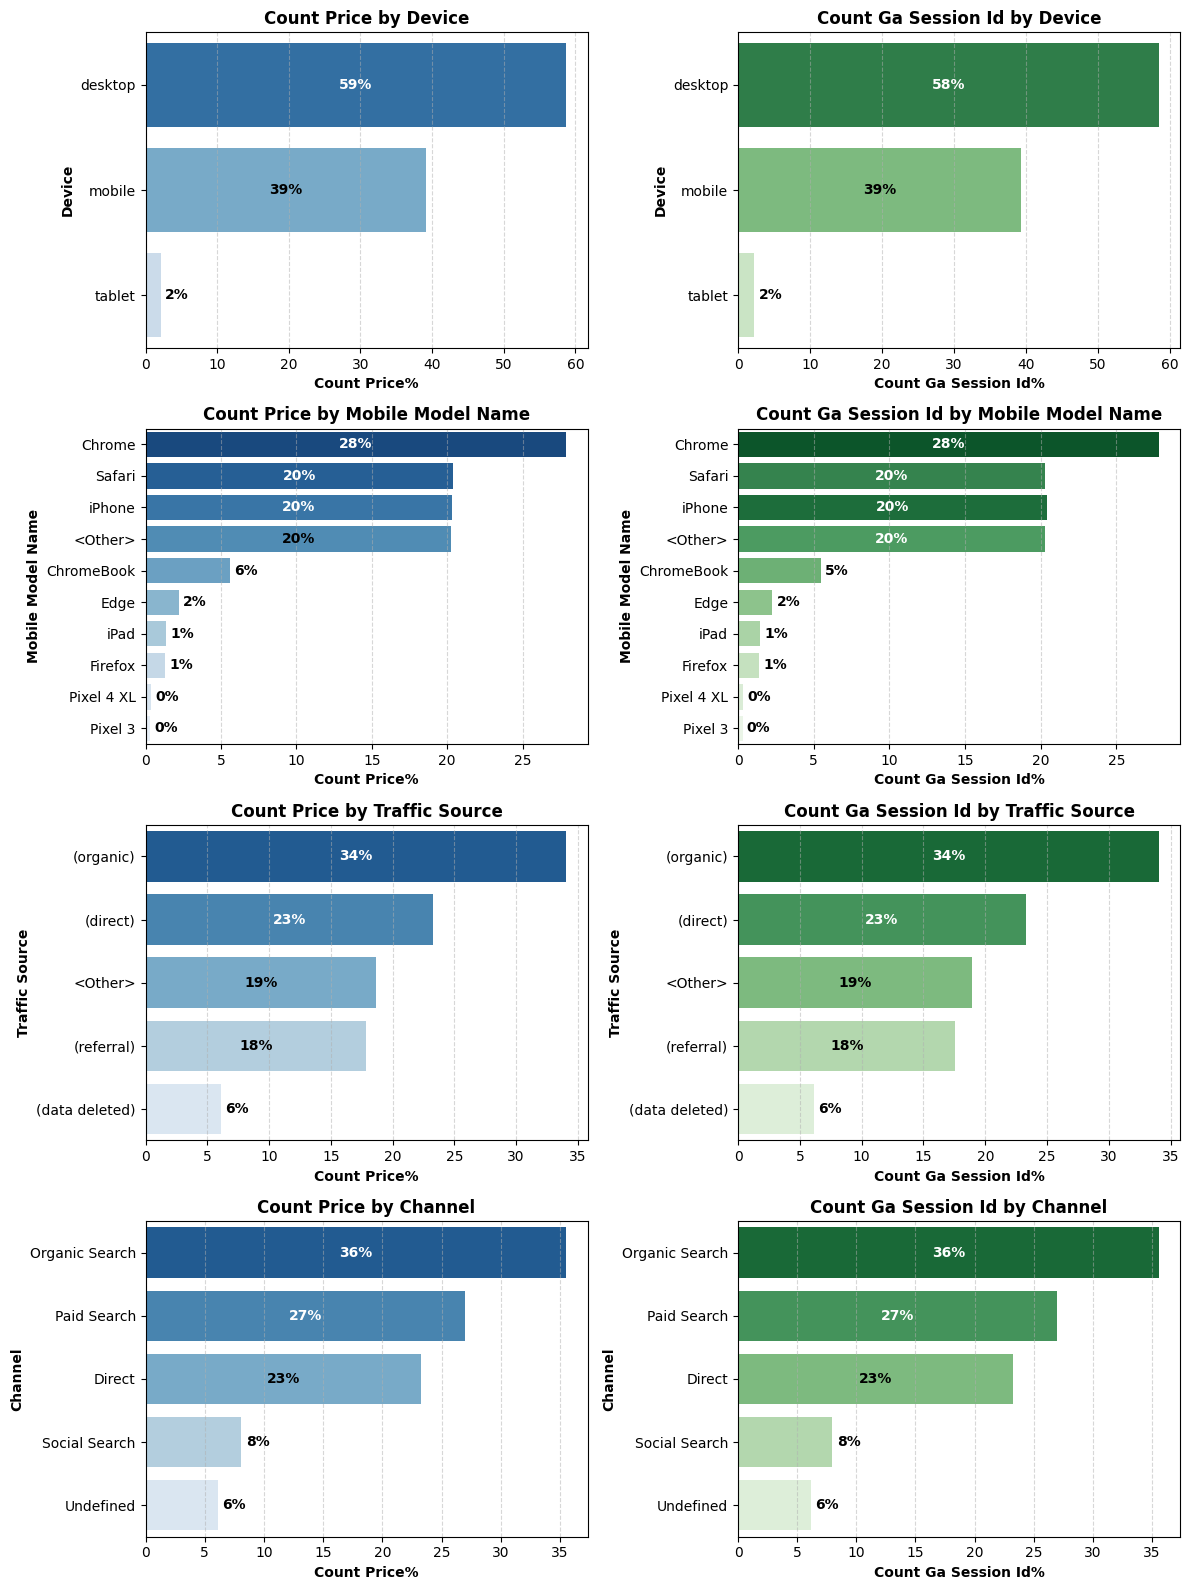

In [ ]:
# Building charts sales percentage of total by...

resalt = plot_metric_by_y(
        df,
        {
            "price": ["count"],
            "ga_session_id":["count"]
            },
        [
            'device',
            'mobile_model_name',
            'traffic_source',
            'channel'
            ],
        normalize=True, ascending=False
)


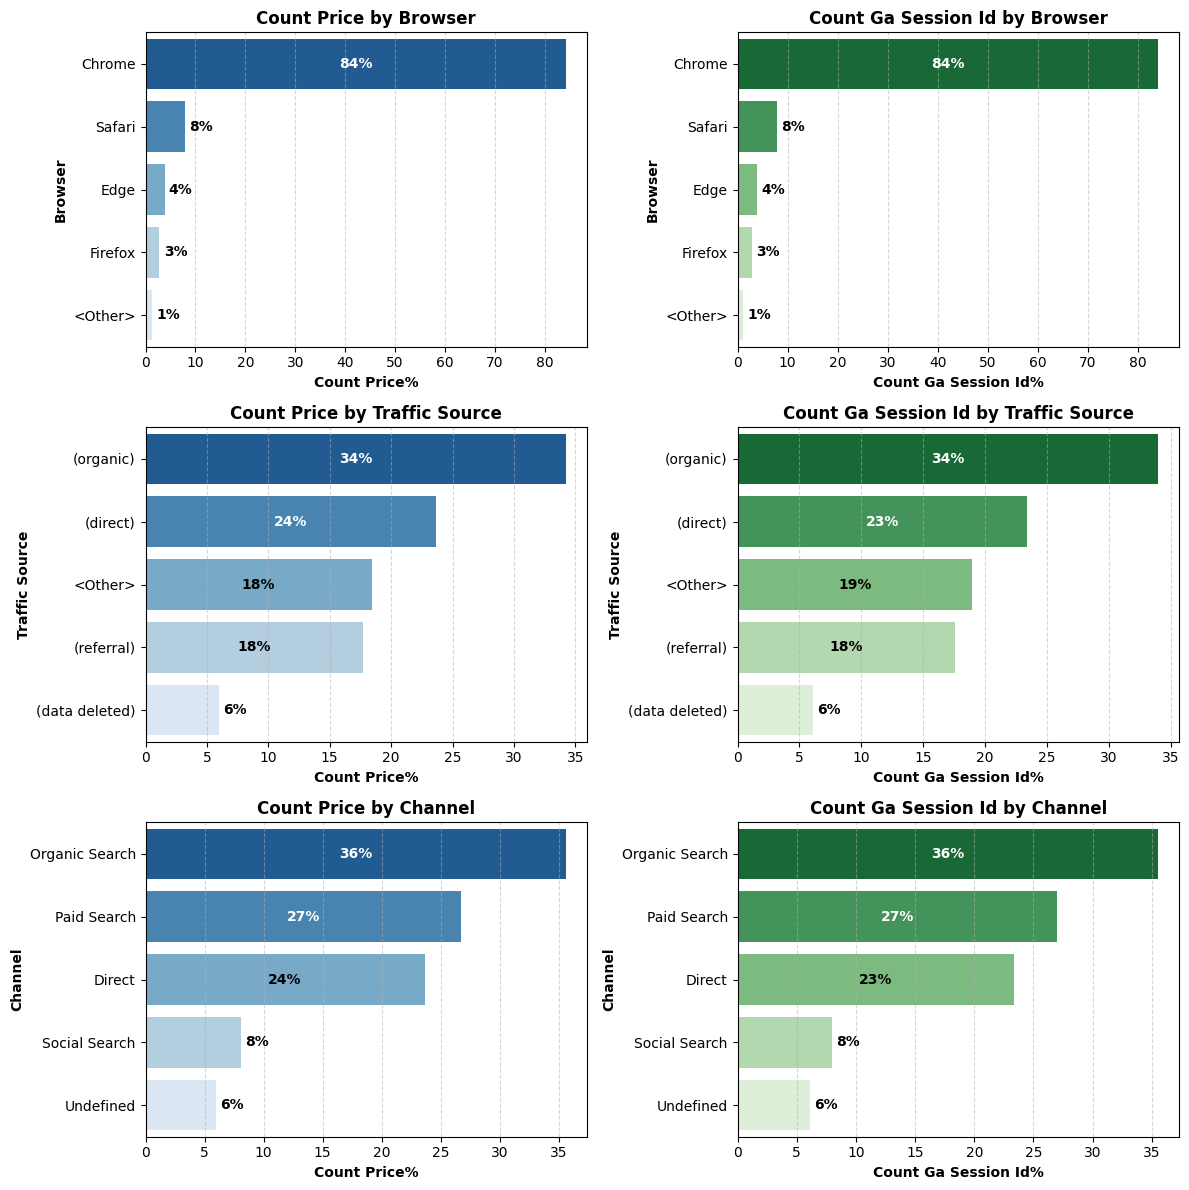

In [ ]:
# Filter desktop device
df_desktop = df[df['device']=="desktop"]
resalt = plot_metric_by_y(
        df_desktop,
        {
            "price": ["count"],
            "ga_session_id":["count"]
            },
        [
            'browser',
            'traffic_source',
            'channel'
            ],
        normalize=True, ascending=False
)

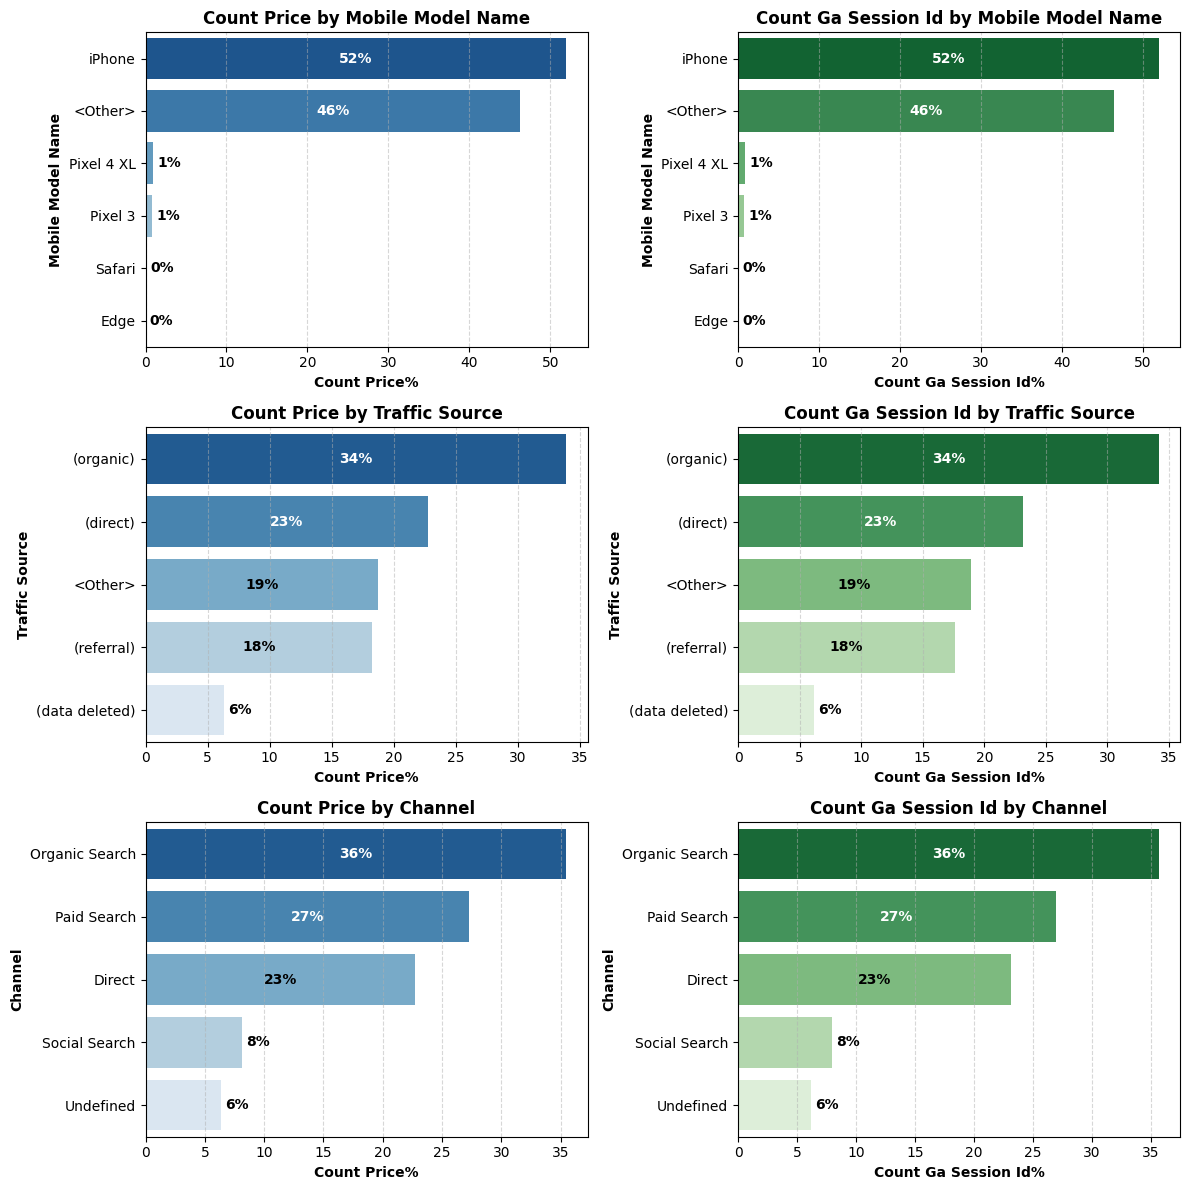

In [ ]:
# Filter mobile device
df_mobile = df[df['device']=="mobile"]
resalt = plot_metric_by_y(
        df_mobile,
        {
            "price": ["count"],
            "ga_session_id":["count"]
            },
        [
            'mobile_model_name',
            'traffic_source',
            'channel'
            ],
        normalize=True, ascending=False
)

#### Description
* 59% of orders were made from desktop devices, of which 84% from Chrome.
* 39% from mobile devices, of which 52% from iPhone.
* 69% used Chrome during sessions.
* 24% used Safari.
* The distribution of traffic sources is the same for all device types:
** Organic 34%
** Direct 23% – 24%

#### Опис
* 59% замовлень було зроблено з настільних пристроїв, з них 84% з Chrome.
* 39% з мобільних пристроїв, з яких 52% з iPhone.
* 69% використовували Chrome під час сеансів.
* 24% використовували Safari.
* Розподіл джерел трафіку однаковий для всіх типів пристроїв:
** Органічний 34%
** Прямий 23% – 24%


#### Analysis of registered users
#### Аналіз зареєстрованих користувачів

In [ ]:


count_orders_total = df['ga_session_id'].nunique() # Total number of order
count_orders_with_account = df[df["account_id"] > 0]["ga_session_id"].nunique() # number of order with account
order_with_account_percentage = (count_orders_with_account / count_orders_total
                                 * 100) if count_orders_total else 0 # percentage order with account

print(f"Number of customers who have account: {count_orders_with_account} persons")
print(f"Number of orders from registered users as a percentage of the total: {order_with_account_percentage:.2f}%")

total_users = df['account_id'].nunique() # Total number of unique accounts
verified_users = df[df['is_verified'] == True]['account_id'].nunique()  # Unique verified accounts
verified_rate = (verified_users / total_users) * 100  # Percentage of verified

print(f"Percentage of registered users who verified their email: {verified_rate:.2f}%")

unsubscribed_users = df[df['is_unsubscribed'] == True]['account_id'].nunique() # Unique unsubscribed accounts
unsubscribed_rate = (unsubscribed_users / total_users) * 100 # Percentage of unsubscribed

print(f"Percentage of registered users who unsubscribed: {unsubscribed_rate:.2f}%")




Number of customers who have account: 27945 persons
Number of orders from registered users as a percentage of the total: 7.99%
Percentage of registered users who verified their email: 71.70%
Percentage of registered users who unsubscribed: 16.94%


In [ ]:


#Filter only users with an account(account_id > 0)
df_orders = df[df["account_id"] > 0]

# Group by subscription status
df_orders_grouped = df_orders.groupby("is_unsubscribed").agg(
    total_orders=("ga_session_id", "nunique"),
    total_users=("account_id", "nunique"),
    total_revenue=("price", "sum"),
    avg_order_value=("price", "mean"),
    verified_users=("is_verified", "sum")

).reset_index()

# Adding new metrics
df_orders_grouped["orders_per_user"] = df_orders_grouped["total_orders"] / df_orders_grouped["total_users"]
df_orders_grouped["verified_users_percent"] = df_orders_grouped["verified_users"] / df_orders_grouped["total_users"] * 100


print(df_orders_grouped)


   is_unsubscribed  total_orders  total_users  total_revenue  avg_order_value  \
0            False         23210        23210   2.150797e+06       921.506836   
1             True          4735         4735   4.317216e+05       965.820129   

   verified_users  orders_per_user  verified_users_percent  
0           15732              1.0               67.781129  
1            4304              1.0               90.897571  


In [ ]:
df_orders_grouped_verified = df_orders.groupby("is_verified").agg(
    total_orders=("ga_session_id", "nunique"),
    total_users=("account_id", "nunique"),
    total_revenue=("price", "sum"),
    avg_order_value=("price", "mean"),
    unsubscribed_users=("is_unsubscribed", "sum")

).reset_index()

# Adding new metrics
df_orders_grouped_verified["orders_per_user"] = df_orders_grouped_verified["total_orders"] / df_orders_grouped_verified["total_users"]
df_orders_grouped_verified["verified_users_percent"] = df_orders_grouped_verified["unsubscribed_users"] / df_orders_grouped_verified["total_users"] * 100


print(df_orders_grouped_verified)

   is_verified  total_orders  total_users  total_revenue  avg_order_value  \
0        False          7909         7909     716501.125       904.673157   
1         True         20036        20036    1866017.375       938.168640   

   unsubscribed_users  orders_per_user  verified_users_percent  
0                 431              1.0                5.449488  
1                4304              1.0               21.481334  


In [ ]:


# We divide the data into two groups by subscription status
subscribed_aov = df[df["is_unsubscribed"] == False]["price"]
unsubscribed_aov = df[df["is_unsubscribed"] == True]["price"]

# Checking statistical significance
compare_group_means(subscribed_aov, unsubscribed_aov)


Mann-Whitney U test results:
Statistic: nan, p-value: nan
Result: No statistically significant difference - Cannot conclude that the first group has a higher mean.


(np.float32(nan), np.float32(nan))

In [ ]:
# We divide the data into two groups by subscription status
verified_aov = df[df["is_verified"] == False]["price"]
unverified_aov = df[df["is_verified"] == True]["price"]

# Checking statistical significance
compare_group_means(verified_aov, unverified_aov)

Mann-Whitney U test results:
Statistic: nan, p-value: nan
Result: No statistically significant difference - Cannot conclude that the first group has a higher mean.


(np.float32(nan), np.float32(nan))

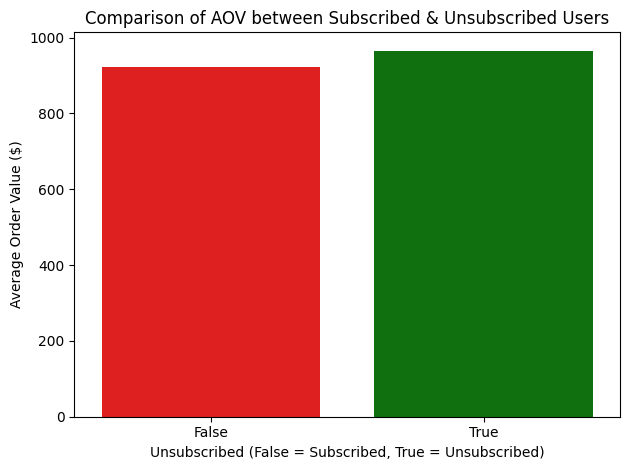

In [ ]:
sns.barplot(data=df_orders_grouped, x="is_unsubscribed",hue="is_unsubscribed", y="avg_order_value",
            palette=["red", "green"], legend=False)
plt.xlabel("Unsubscribed (False = Subscribed, True = Unsubscribed)")
plt.ylabel("Average Order Value ($)")
plt.title("Comparison of AOV between Subscribed & Unsubscribed Users")

plt.tight_layout()
plt.show()


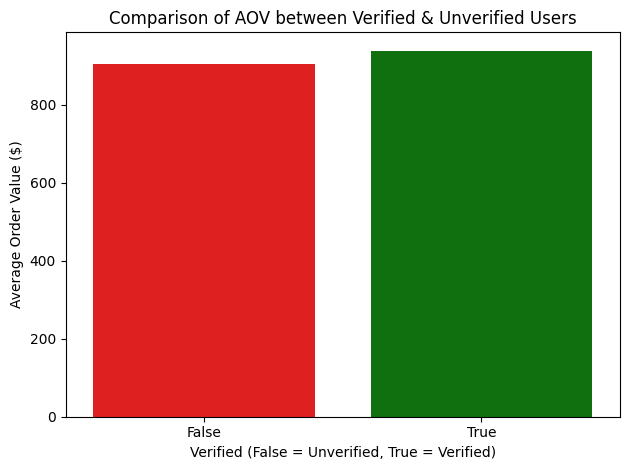

In [ ]:
sns.barplot(data=df_orders_grouped_verified, x="is_verified",hue="is_verified",
            y="avg_order_value", palette=["red", "green"], legend=False)
plt.xlabel("Verified (False = Unverified, True = Verified)")
plt.ylabel("Average Order Value ($)")
plt.title("Comparison of AOV between Verified & Unverified Users")
plt.tight_layout()
plt.show()

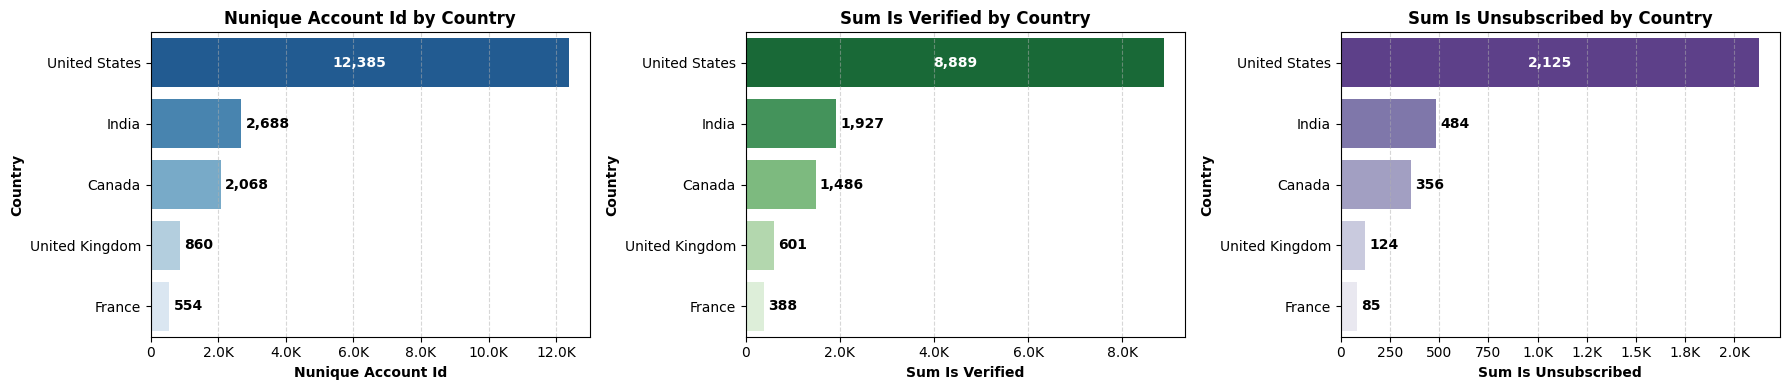

In [ ]:

resalt = plot_metric_by_y(df,
                          {"account_id":["nunique"], "is_verified":["sum"], "is_unsubscribed":["sum"]},
                          ["country"],
                          top_n=5, normalize=False, ascending=False)


#### Result of analysis of registered users
* 27945 users registered.
* Orders from registered users account for 7.99% of total orders.
* The largest number of registered users in the United States.
* User behavior does not change statistically significantly depending on verification and subscription status.
* Registered users do not make repeat orders, or are not authorized to do so.

The low percentage of registrations and the lack of repeat orders indicate that registration and subscription do not provide any benefits.
#### Результат аналізу зареєстрованих користувачів
* 27945 користувачів зареєстровано  .
* Замовлення від зареєстрованих користувачів складають 7,99% від загальної кількості замовлень.
* Найбільша кількість зареєстрованих користувачів у США.
* Поведінка користувача статистично значущо не змінюється залежно від верифікації та статусу підписки.
* Зареєстровані користувачі не роблять повторних замовлень або не авторизуються для цього.

Низький відсоток реєстрацій та відсутність повторних замовлень свідчить про те, що реєстрація та підписка не дають жодних переваг.

#### Analysis of sales dynamics.
#### Аналіз динаміки продажів.

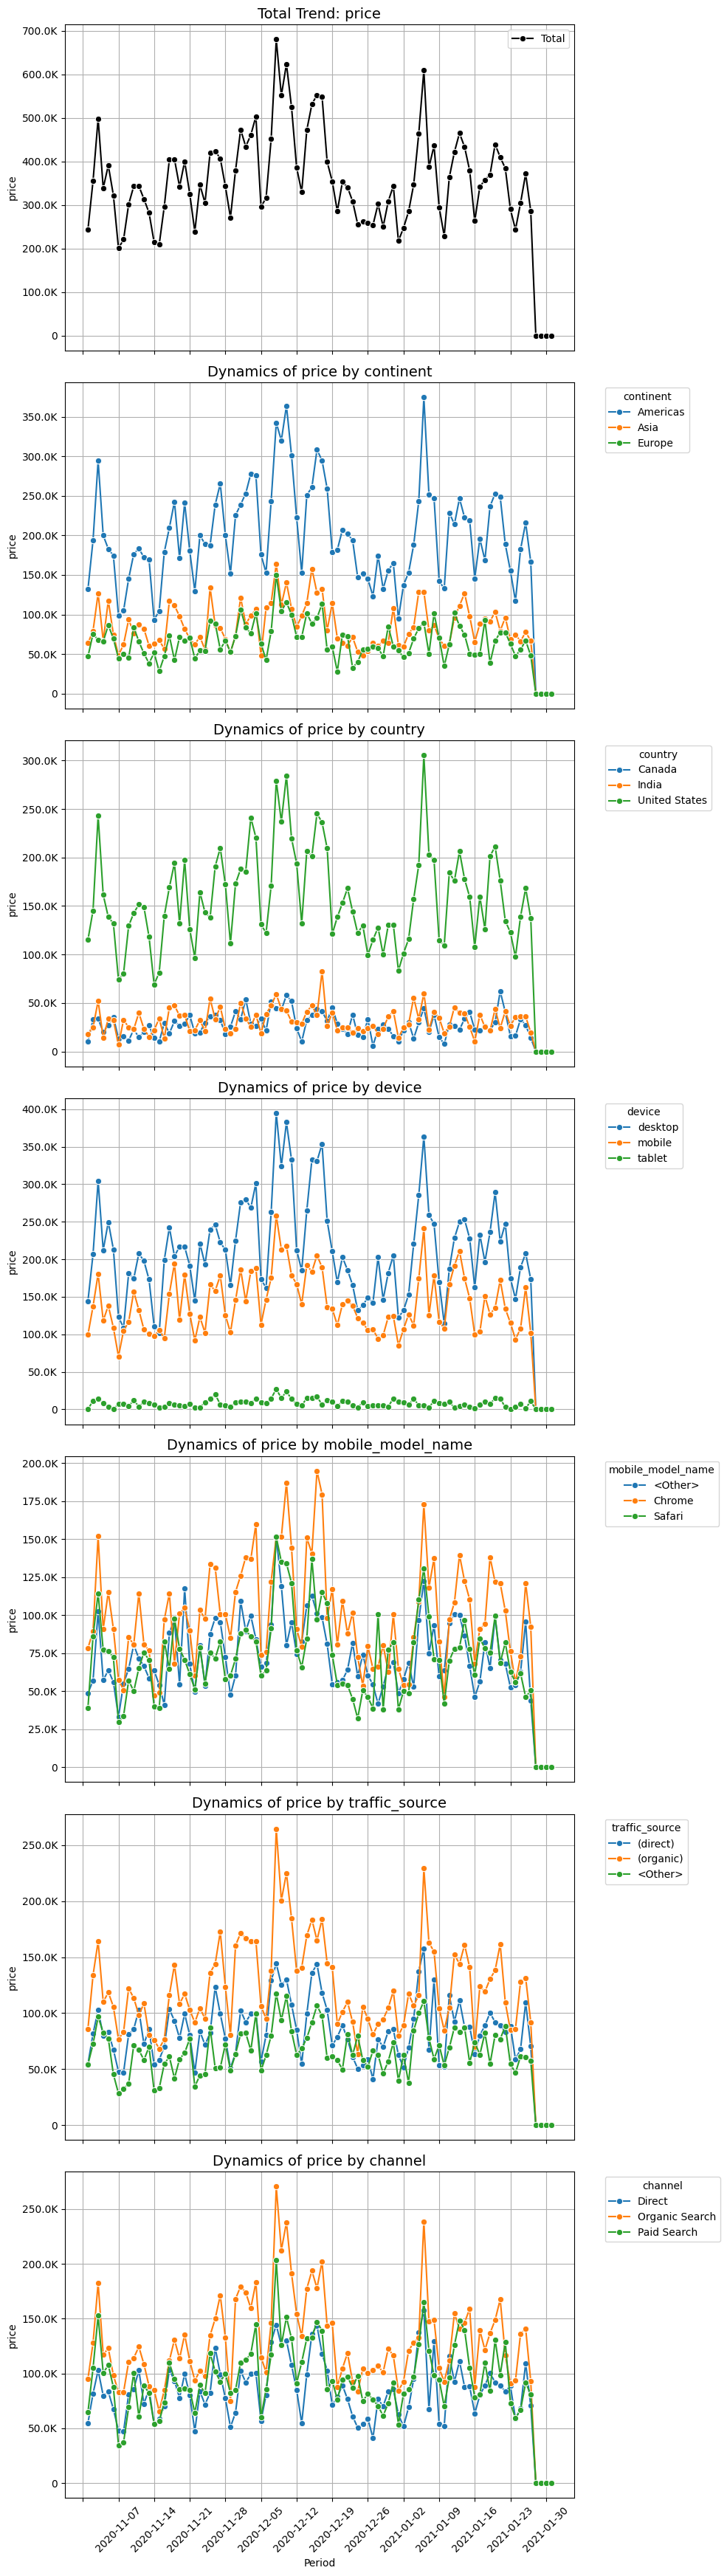

In [ ]:
metrics_dynamics_by_categorical_column(
    data=df,
    date='date',
    period='D',
    metrics=['price'],
    categorical_columns=['continent', 'country', 'device', 'mobile_model_name', 'traffic_source', 'channel'],
    top_n=3
)


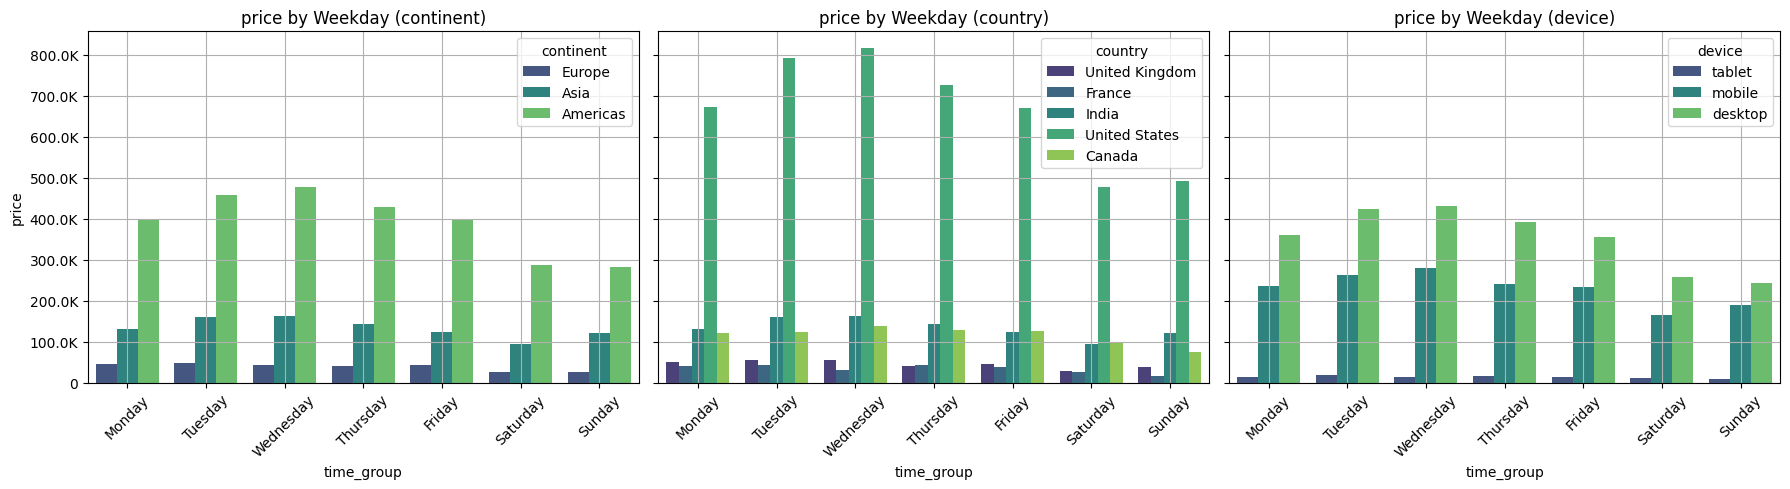

In [ ]:
analyze_trend_by(df, date="date", metrics=["price"], time_period="weekday",
                 categorical_columns=["continent", "country", "device"],
                 top_n=5)


#### Description of the analysis of sales dynamics.
* There is a cyclical change in sales by day of the week. Decrease on weekends.
* There is an increase in sales before the Christmas holidays.
* The trend persists regardless of geographical location.

#### Опис аналізу динаміки продажів.
* Спостерігається циклічна зміна продажів по днях тижня. Зниження у вихідні дні.
* Спостерігається ріст продажів перед різдвяними святами.
* Тенденція зберігається не залежно від географічного положення.

### Pivot table

In [ ]:

# Create pivot table
pivot_table = df.pivot_table(values="ga_session_id", index=["device","channel"], aggfunc="count")
# Sort by count sessions descending
pivot_table = pivot_table.sort_values(by="ga_session_id", ascending=False)

print(pivot_table)


                        ga_session_id
device  channel                      
desktop Organic Search          72622
        Paid Search             55167
mobile  Organic Search          49014
desktop Direct                  47825
mobile  Paid Search             37034
        Direct                  31745
desktop Social Search           16288
        Undefined               12527
mobile  Social Search           10988
        Undefined                8486
tablet  Organic Search           2789
        Paid Search              2140
        Direct                   1812
        Social Search             638
        Undefined                 470


#### Count Sessions by Traffic Channel and Device

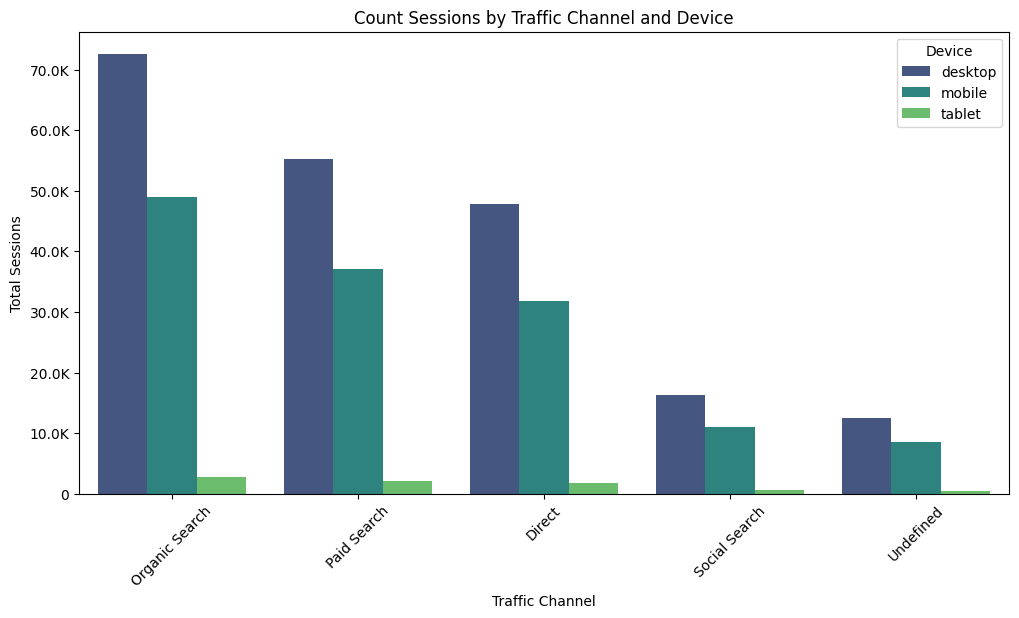

In [ ]:

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="channel", y="ga_session_id", hue="device", data=pivot_table, palette="viridis")
plt.xticks(rotation=45)
plt.title("Count Sessions by Traffic Channel and Device")
plt.ylabel("Total Sessions")
plt.xlabel("Traffic Channel")
plt.legend(title="Device")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_large_numbers))

plt.show()



* The trend in the distribution of the number of sessions across traffic channels is similar across all device types.
* Тенеденція розподілу кількості сесій по каналам трафіку схожа по всім типам пристроїв.

#### Top 10 Product Categories by Sales in Top 5 Countries

In [ ]:


# Filter data from top countries and top categories
filtered_df = df[df["country"].isin(top_5_countries) & df["category"].isin(top_10_categories)]

# Create pivot table
pivot_table = filtered_df.pivot_table(values="price", index="category", columns="country", aggfunc="sum", fill_value=0)

# Sort categories from sales
pivot_table = pivot_table.loc[pivot_table.sum(axis=1).sort_values(ascending=False).index]



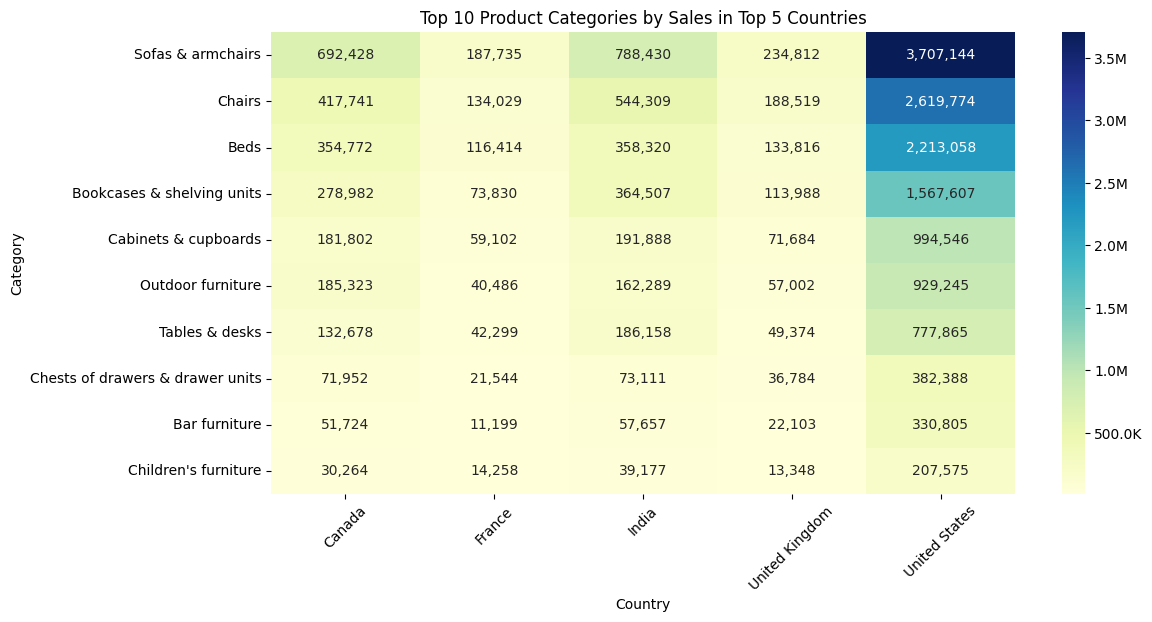

In [ ]:



# Visualization
plt.figure(figsize=(12, 6))
ax = sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=",.0f")

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_large_numbers))


plt.title("Top 10 Product Categories by Sales in Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Category")
plt.xticks(rotation=45)

plt.show()



The trend in category profitability is similar across all top 5 countries and similar to the overall

Тенденція прибутковості категорій схожа в усіх топ-5 країнах та схожа на загальну

#### Traffic Channel by Sales in Top 5 Countries

In [ ]:
# Filter data from top countries and top categories
filtered_df = df[df["country"].isin(top_5_countries)]

# Create pivot table
pivot_table = filtered_df.pivot_table(values="price", index="channel", columns="country", aggfunc="sum", fill_value=0)

# Sort categories from sales
pivot_table = pivot_table.loc[pivot_table.sum(axis=1).sort_values(ascending=False).index]


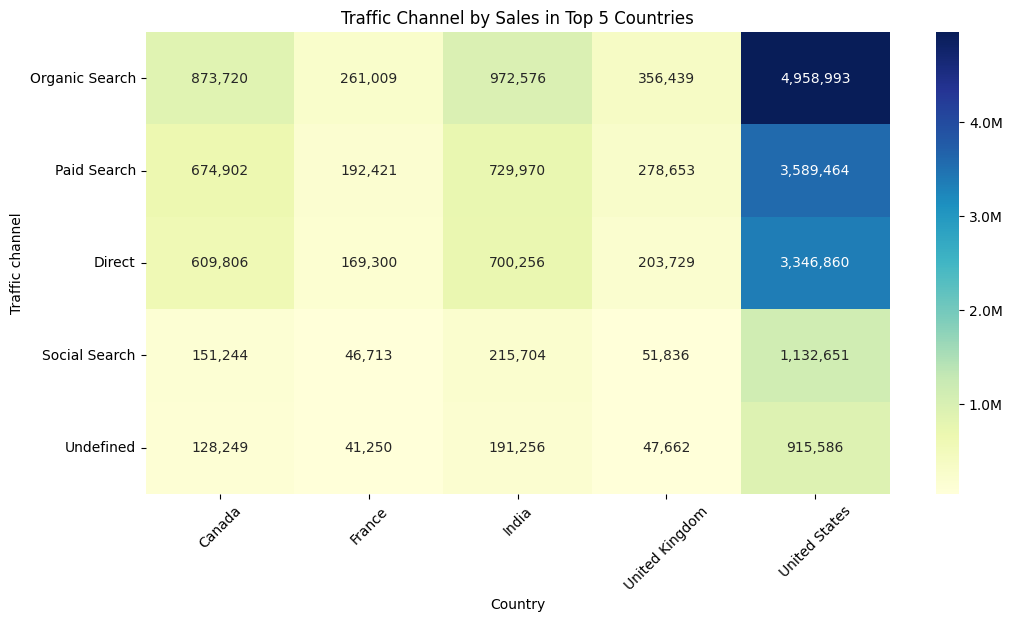

In [ ]:
# Visualization
plt.figure(figsize=(12, 6))
ax = sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=",.0f")

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_large_numbers))


plt.title("Traffic Channel by Sales in Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Traffic channel")
plt.xticks(rotation=45)

plt.show()

The trend in sales distribution by traffic channels is similar for all top 5 countries.
 <br>Top Channel:
* *Organic search*
* *Paid search*
* *Direct*


Тенденція розподілу продажів по каналах трафіку схожа для всіх країн в топ-5
 <br>Топ канали:
* *Organic search*
* *Paid search*
* *Direct*

### Statistical analysis of relationships.
### Статаистичний аналіз взаємозвʼязків.

#### Checking the correlation between the number of sessions and sales.
#### Перевірка кореляції між кількістю сесій та продажами.

Pearson correlation coefficient: 0.79
P-value: 6.4835304698635165e-21
Statistically significant strong correlation between count sessions and sales


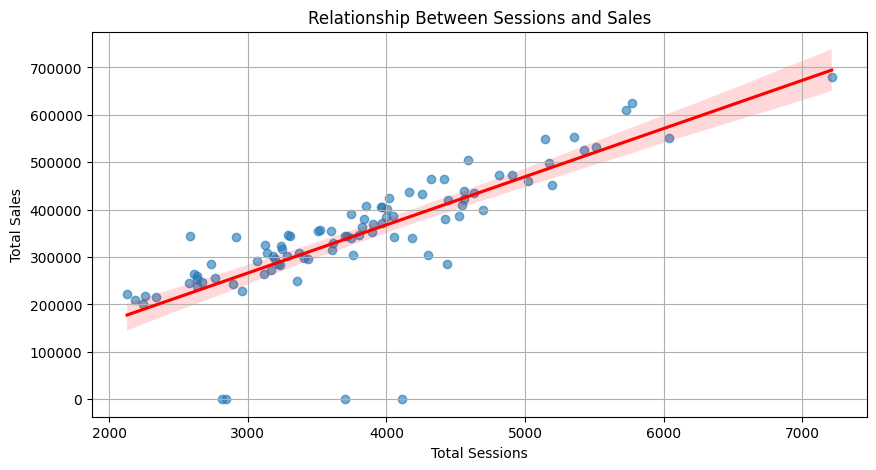

In [ ]:


# Group data by dates
df_daily = df.groupby("date").agg(
    total_sessions=("ga_session_id", "count"),
    total_sales=("price", "sum")
).reset_index()

# Visualizing the correlation between sessions and sales
plt.figure(figsize=(10, 5))
sns.regplot(x=df_daily["total_sessions"], y=df_daily["total_sales"], scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("Relationship Between Sessions and Sales")
plt.xlabel("Total Sessions")
plt.ylabel("Total Sales")
plt.grid(True)

# Calculating the correlation coefficient
corr_coef, p_value = pearsonr(df_daily["total_sessions"], df_daily["total_sales"])


print(f"Pearson correlation coefficient: {corr_coef:.2f}")
print(f"P-value: {p_value}")
if p_value < 0.05 and corr_coef > 0.7:
    print("Statistically significant strong correlation between count sessions and sales")
elif p_value < 0.05 and corr_coef > 0.4 and corr_coef < 0.7:
    print("Statistically significant medium correlation between count sessions and sales")
elif p_value < 0.05 and corr_coef < 0.04:
    print("Statistically significant weak correlation between count sessions and sales")
else: print("The correlation is not statistically significant.")


plt.show()


There is a noticeable strong positive correlation between the number of sessions and sales.

Помітна сильна позитивна кореляція між кількістю сесій та продажами.

#### Checking the correlation of sales by continent.
#### Перевірка кореляції продажів по континентам.

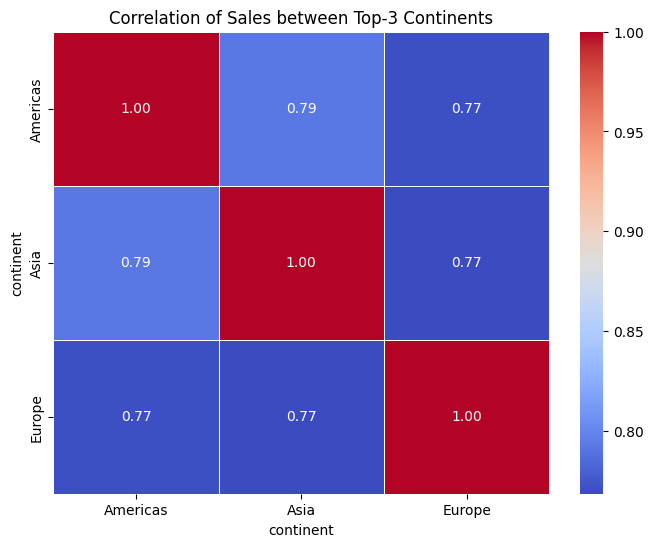

P-values for correlation significance:
continent      Americas          Asia        Europe
continent                                          
Americas   1.000000e+00  5.409190e-21  2.671446e-19
Asia       5.409190e-21  1.000000e+00  3.864948e-19
Europe     2.671446e-19  3.864948e-19  1.000000e+00


In [ ]:


# Aggregation of sales by continent
df_continent_sales = df.groupby(["date", "continent"])["price"].sum().reset_index()

# Selection of the top 3 continents by total sales
df_top = df_continent_sales[df_continent_sales["continent"].isin(top_3_continents)]

# Transformation into a pivot table
df_pivot = df_top.pivot(index="date", columns="continent", values="price")

# Calculating correlation
corr_matrix = df_pivot.corr()

# Checking the statistical significance of the correlation
p_values = df_pivot.corr(method=lambda x, y: pearsonr(x, y)[1])  # Отримуємо p-values

# Visualization of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
plt.title("Correlation of Sales between Top-3 Continents")
plt.show()

# Output p-values ​​for significance testing
print("P-values for correlation significance:")
print(p_values)


There is a strong positive statistically significant correlation in sales between continents.

Помітна сильна позитивна статистично значуща кореляція продажів між континентами.


#### Checking sales correlation between traffic channels.
#### Перевірка кореляції продажів по каналах трафіку.

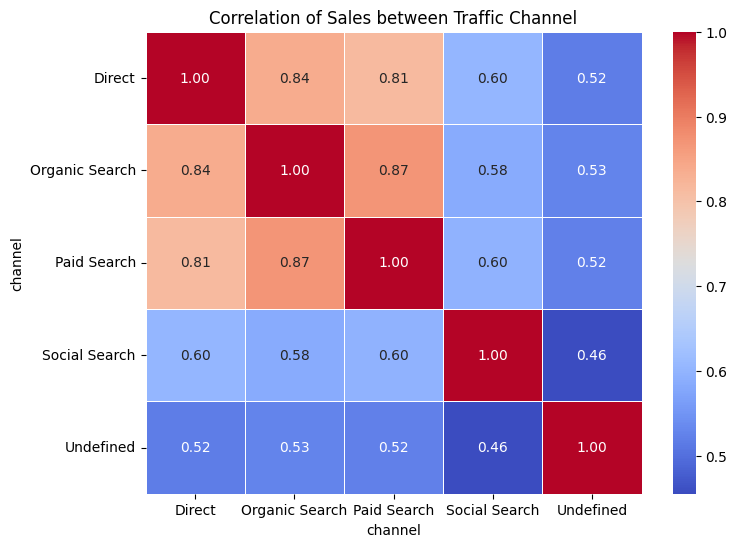

P-values for correlation significance:
channel               Direct  Organic Search   Paid Search  Social Search  \
channel                                                                     
Direct          1.000000e+00    2.190417e-25  5.896432e-23   1.831888e-10   
Organic Search  2.190417e-25    1.000000e+00  2.142000e-29   1.066192e-09   
Paid Search     5.896432e-23    2.142000e-29  1.000000e+00   3.532281e-10   
Social Search   1.831888e-10    1.066192e-09  3.532281e-10   1.000000e+00   
Undefined       1.275436e-07    7.228212e-08  9.509605e-08   5.161928e-06   

channel            Undefined  
channel                       
Direct          1.275436e-07  
Organic Search  7.228212e-08  
Paid Search     9.509605e-08  
Social Search   5.161928e-06  
Undefined       1.000000e+00  


In [ ]:
# Aggregation of sales by channel
df_channel_sales = df.groupby(["date", "channel"])["price"].sum().reset_index()


# Transformation into a pivot table
df_pivot = df_channel_sales.pivot(index="date", columns="channel", values="price")

# Calculating correlation
corr_matrix = df_pivot.corr()

# Checking the statistical significance of the correlation
p_values = df_pivot.corr(method=lambda x, y: pearsonr(x, y)[1])  # Отримуємо p-values

# Visualization of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
plt.title("Correlation of Sales between Traffic Channel")
plt.show()

# Output p-values ​​for significance testing
print("P-values for correlation significance:")
print(p_values)

A positive, statistically significant sales correlation across traffic channels is observed, ranging from medium to strong. The more sales across channels, the stronger the correlation between them.

Помітна позитивна, статистично значуща кореляція продажів по каналах трафіку від середньої до сильної. Чим більше продажів по каналах тим сильніша між ними кореляція.



#### Checking sales correlation between different categories from the Top-10.

#### Перевірка кореляції продажів між різними категоріями з Топ-10.

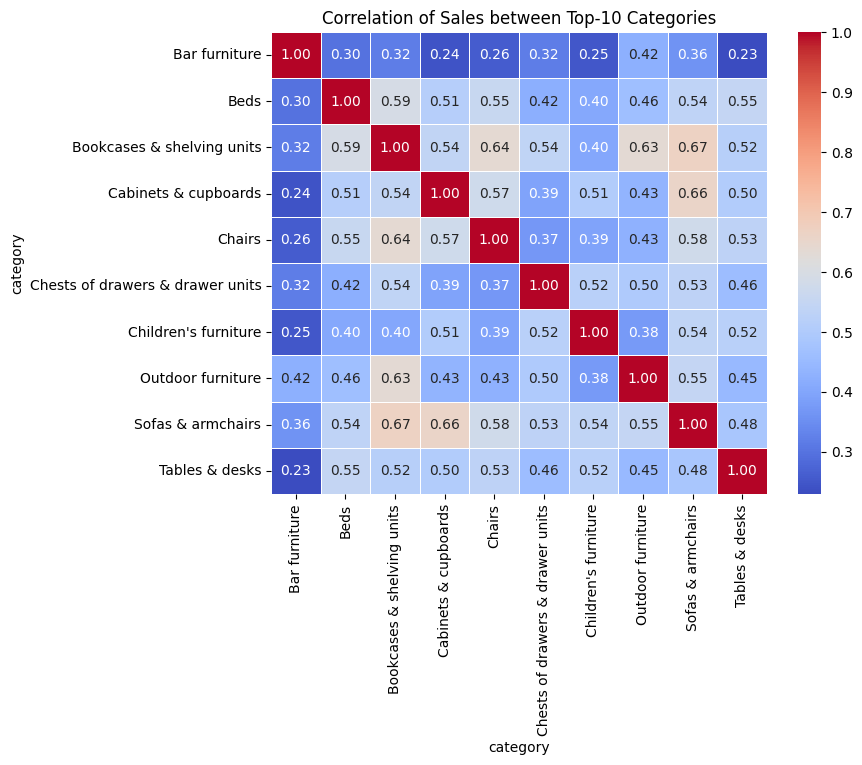

P-values for correlation significance:
category                          Bar furniture          Beds  \
category                                                        
Bar furniture                          1.000000  4.942053e-03   
Beds                                   0.004942  1.000000e+00   
Bookcases & shelving units             0.002531  1.154998e-09   
Cabinets & cupboards                   0.022591  2.910930e-07   
Chairs                                 0.015304  2.079183e-08   
Chests of drawers & drawer units       0.002517  4.345762e-05   
Children's furniture                   0.019198  9.125745e-05   
Outdoor furniture                      0.000042  5.297728e-06   
Sofas & armchairs                      0.000541  7.687333e-08   
Tables & desks                         0.031735  3.718394e-08   

category                          Bookcases & shelving units  \
category                                                       
Bar furniture                                   2.53

In [ ]:
# Aggregation of sales by channel
df_category_sales = df.groupby(["date", "category"])["price"].sum().reset_index()
df_top_category_sales = df_category_sales[df_category_sales["category"].isin(top_10_categories)]

# Transformation into a pivot table
df_pivot = df_top_category_sales.pivot(index="date", columns="category", values="price")

# Calculating correlation
corr_matrix = df_pivot.corr()

# Checking the statistical significance of the correlation
p_values = df_pivot.corr(method=lambda x, y: pearsonr(x, y)[1])

# Visualization of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True)
plt.title("Correlation of Sales between Top-10 Categories")
plt.show()

# Output p-values ​​for significance testing
print("P-values for correlation significance:")
print(p_values)

The correlation between sales of different product categories is statistically significant, ranging from a weak 0.23 to a medium 0.67.

Кореляція між продажами різних категорій товарів статистично значуща, від слабкої 0.23 до середньої 0.67.

In [ ]:
df.columns

Index(['date', 'ga_session_id', 'continent', 'country', 'device', 'browser',
       'mobile_model_name', 'operating_system', 'language', 'traffic_source',
       'channel', 'account_id', 'is_verified', 'is_unsubscribed', 'category',
       'product', 'price', 'short_description', 'period', 'time_group'],
      dtype='object')

#### Statistical analysis of differences between groups
#### Статистичний аналіз відмінностей між групами

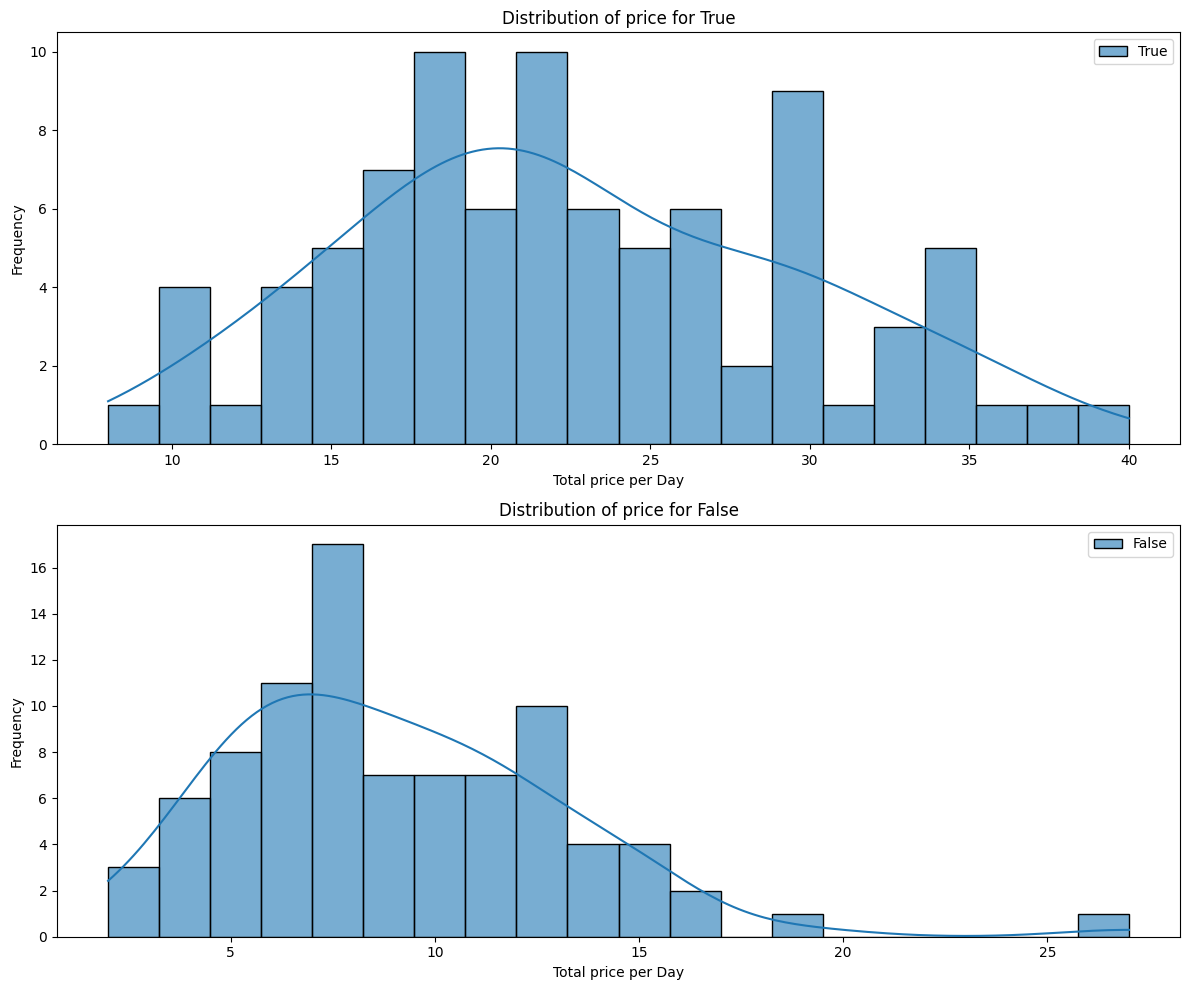

Shapiro-Wilk Test: is_verified True p-value = 0.2930246959239758
D'Agostino's Test: is_verified True p-value = 0.27059083827289415
is_verified True has normal distribution.

Shapiro-Wilk Test: is_verified False p-value = 0.00015376402513769824
D'Agostino's Test: is_verified False p-value = 2.2364530475544806e-06
is_verified False has non-normal distribution.


📊 Applied Test: Mann-Whitney U test
Test Statistic: 7428.5000
p-value: 6.281387756768636e-26
❗ There is a statistically significant difference between the groups.


In [ ]:
check_distribution_and_test(df, "is_verified", "price", True, False, agg_func="count")

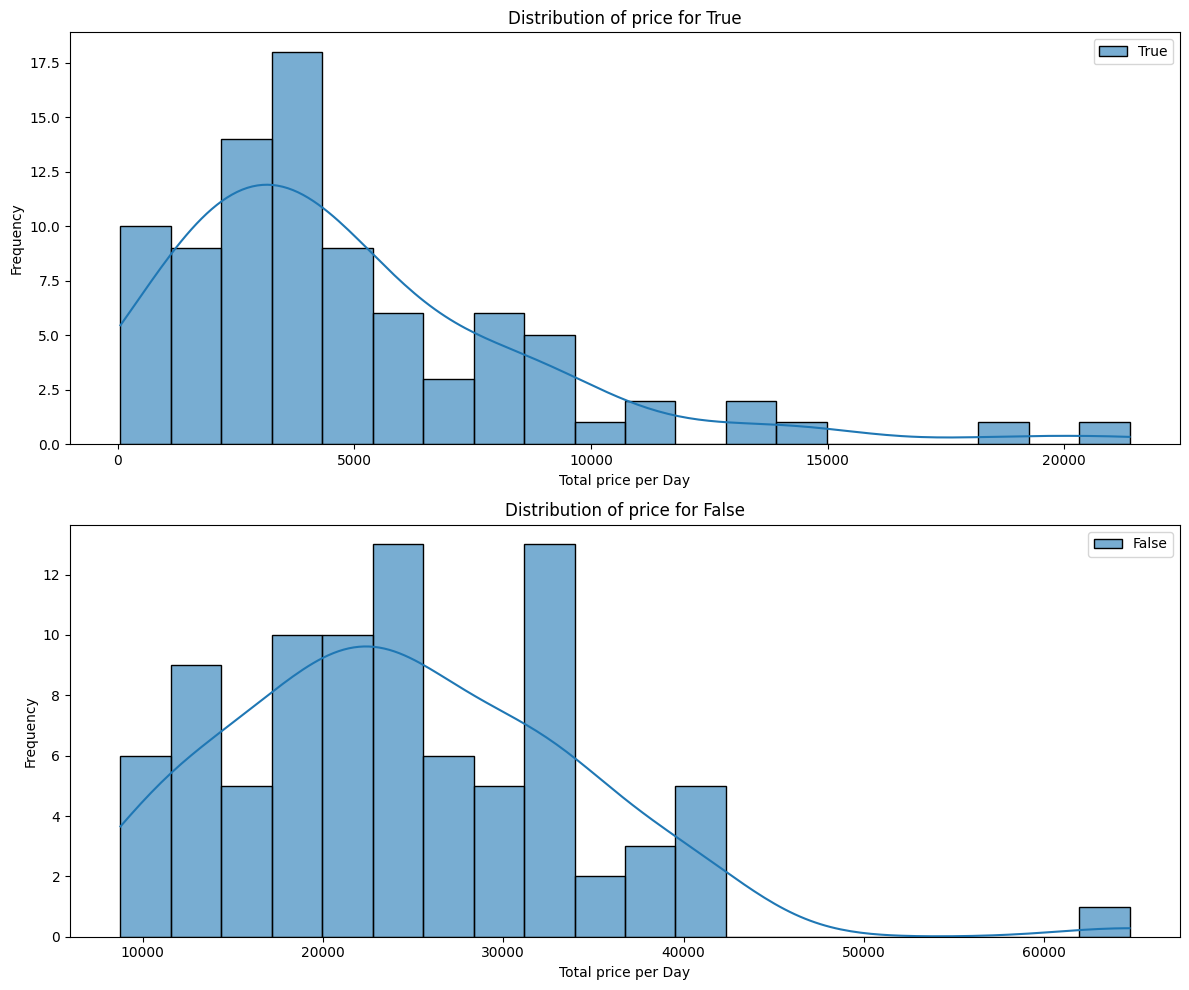

Shapiro-Wilk Test: is_unsubscribed True p-value = 4.087640337245145e-08
D'Agostino's Test: is_unsubscribed True p-value = 7.811061267218961e-10
is_unsubscribed True has non-normal distribution.

Shapiro-Wilk Test: is_unsubscribed False p-value = 0.0018539937732145295
D'Agostino's Test: is_unsubscribed False p-value = 0.0002824378583535226
is_unsubscribed False has non-normal distribution.


📊 Applied Test: Mann-Whitney U test
Test Statistic: 125.0000
p-value: 1.4787066504202697e-28
❗ There is a statistically significant difference between the groups.


In [ ]:
check_distribution_and_test(df, "is_unsubscribed", "price", True, False, agg_func="sum")

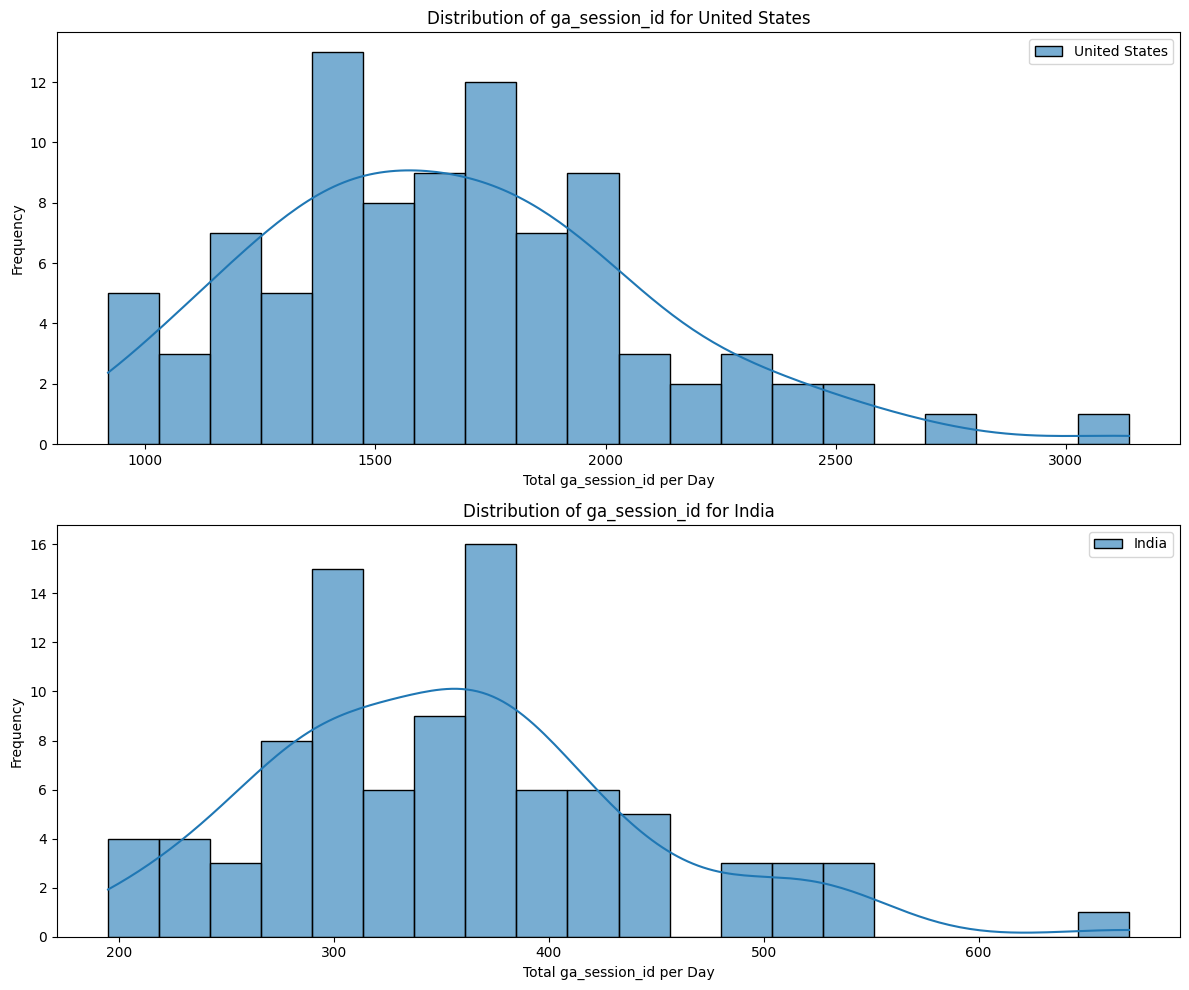

Shapiro-Wilk Test: country United States p-value = 0.04074546231141041
D'Agostino's Test: country United States p-value = 0.014288045325128049
country United States has non-normal distribution.

Shapiro-Wilk Test: country India p-value = 0.008135330194505732
D'Agostino's Test: country India p-value = 0.0037406346955122433
country India has non-normal distribution.


📊 Applied Test: Mann-Whitney U test
Test Statistic: 8464.0000
p-value: 1.0772147300537953e-31
❗ There is a statistically significant difference between the groups.


In [ ]:
check_distribution_and_test(df, "country", "ga_session_id", "United States", "India", agg_func="count")

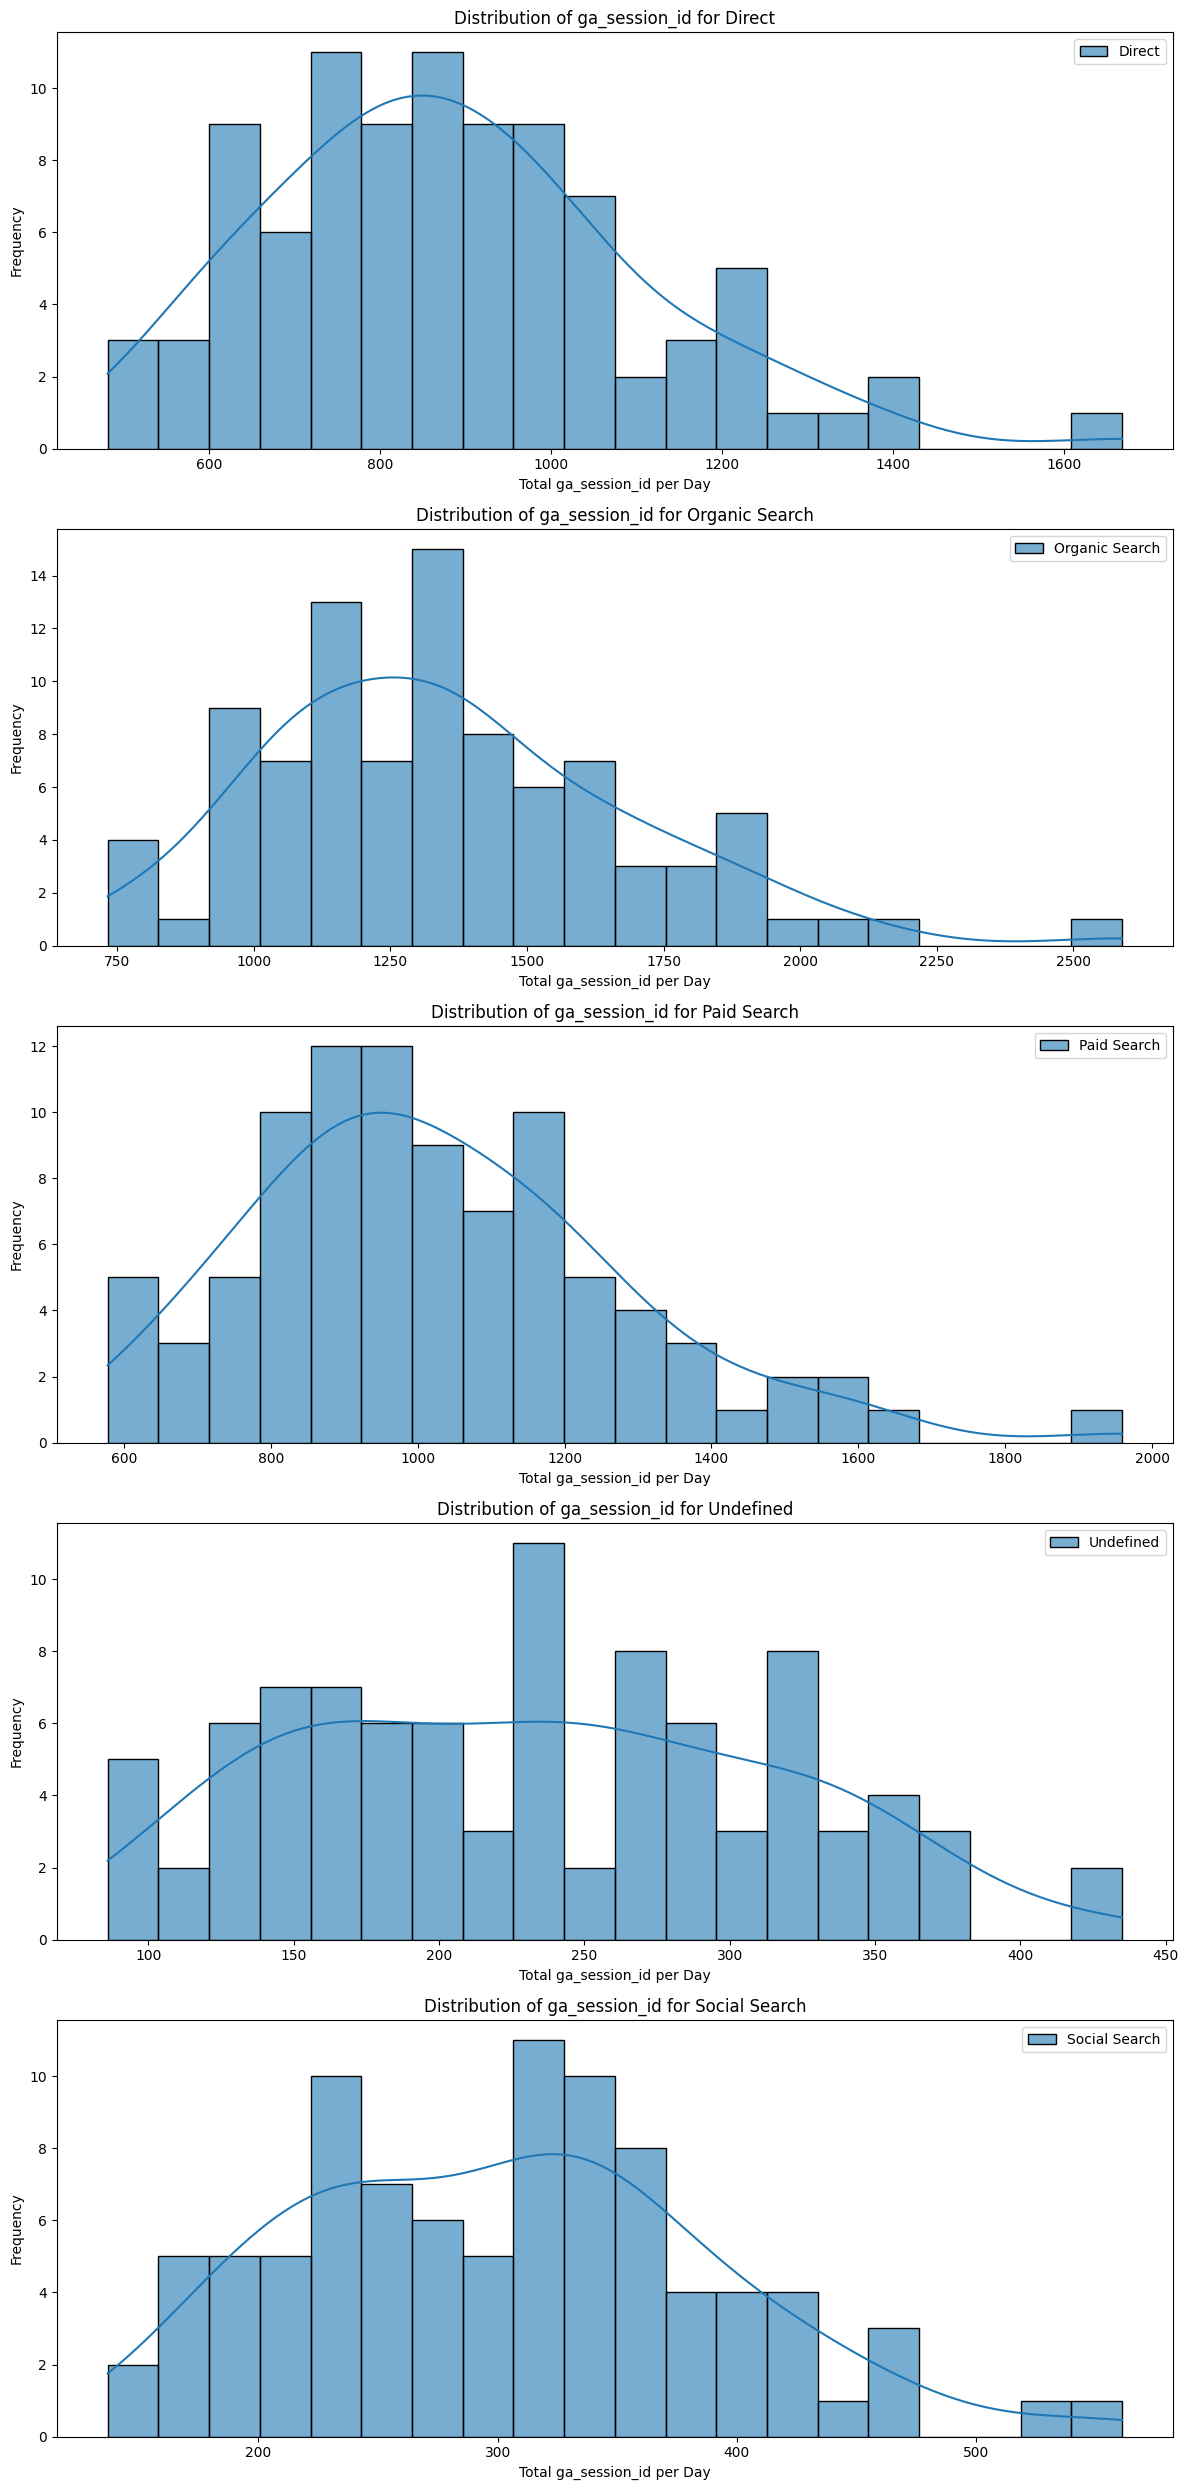

Shapiro-Wilk Test: channel Direct p-value = 0.034278771626201326
D'Agostino's Test: channel Direct p-value = 0.007853358264896217
channel Direct has non-normal distribution.

Shapiro-Wilk Test: channel Organic Search p-value = 0.012271774671209374
D'Agostino's Test: channel Organic Search p-value = 0.0031046084804515037
channel Organic Search has non-normal distribution.

Shapiro-Wilk Test: channel Paid Search p-value = 0.010833125972481636
D'Agostino's Test: channel Paid Search p-value = 0.0016504167955096551
channel Paid Search has non-normal distribution.

Shapiro-Wilk Test: channel Undefined p-value = 0.054564615910193105
D'Agostino's Test: channel Undefined p-value = 0.0402046864129123
channel Undefined has non-normal distribution.

Shapiro-Wilk Test: channel Social Search p-value = 0.14127184979117535
D'Agostino's Test: channel Social Search p-value = 0.21439918696878835
channel Social Search has normal distribution.


📊 Applied Test: Kruskal-Wallis test
Test Statistic: 368.9806


In [ ]:
check_distribution_and_test(df, "channel", "ga_session_id", 'Direct', 'Organic Search', 'Paid Search', 'Undefined',
       'Social Search', agg_func="count")

### Conclusions and recommendations.

* Total count session: 349,545
* Total Sales: 31,971,726 $
* Total Number of Orders: 33,538
* Average Selling Price: 953.30 USD
* TOP-3 Continents by Sales: Americas, Asia, Europe
* TOP-5 Countries by Sales: United States, India, Canada, United Kingdom, France
* TOP-10 Categories by Sales: Sofas & armchairs, Chairs, Beds, Bookcases & shelving units, Cabinets & cupboards, Outdoor furniture, Tables & desks, Chests of drawers & drawer units, Bar furniture, Children's furniture

It is worth paying attention to the categories:

* Sofas & armchairs is the first in the top in terms of profitability, the third in terms of popularity. This indicates a high margin. It is necessary to analyze the possibility of increasing popularity. Develop a hypothesis and test it. High margin usually allows you to apply discounts and promotions.
* Bookcases & shelving units is the most popular category, in 4th place in terms of profitability. This indicates a low margin. It is necessary to analyze the pricing policy in this category. Perhaps an increase in price will lead to an increase in profit.

The same trend across categories persists for Top Continents and Top Countries.

* 59% of orders were made from desktop devices, of which 84% from Chrome.
* 39% from mobile devices, of which 52% from iPhone.
* 69% used Chrome during sessions.
* 24% used Safari.

The distribution of traffic sources is the same for all device types:
* Organic 34%
* Direct 23% – 24%

Number of customers who have account: 27945 persons
Number of orders from registered users as a percentage of the total: 7.99%
<br>Percentage of registered users who verified their email: 71.70%
<br>Percentage of registered users who unsubscribed: 16.94%
<br>The largest number of registered users in the United States.
<br>User behavior does not change statistically significantly depending on verification and subscription status.
<br>Registered users do not make repeat orders, or are not authorized to do so.
<br>The low percentage of registrations and the lack of repeat orders indicate that registration and subscription do not provide any benefits.

Analysis of sales dynamics.
<br>There is a cyclical change in sales by day of the week. Decrease on weekends.
<br>There is an increase in sales before the Christmas holidays.
<br>The trend persists regardless of geographical location.

The trend in the distribution of the number of sessions across traffic channels is similar across all device types.

The trend in sales distribution by traffic channels is similar for all top 5 countries.
Top Channel:
* Organic search
* Paid search
* Direct

There is a noticeable strong positive correlation between the number of sessions and sales.

#### Recommendations.
For the Sofas & armchairs category, develop a hypothesis and use AB testing to test the possibility of using promotions and discounts to increase popularity.
<br>For the Bookcases & shelving units category, review the pricing policy, develop a hypothesis and use AB testing to test the possibility of increasing prices.

### Висновки та рекомендації.
Варто звернути увагу на категорії:

* Sofas & armchairs перша в топі за прибутковістю, третя за популярністю. Це свідчить про високу маржинальність. Потрібно проаналізувати можливість збільшення популярності. Розробити гіпотезу та перевірити її. Висока маржинальність зазвичай дозволяє застосувати знижки та акції.
* Bookcases & shelving units найпопулярніша категорія, на 4 місці за прибутковістю. Це свідчить про низьку маржинальність. Потрібно проаналізувати цінову політику в цій категорії. Можливо збільшення ціни приведе до росту прибутку.

Така сама тенденція по категоріях зберігається для Топ континентів та Топ країн.

* 59% замовлень було зроблено з настільних пристроїв, з них 84% з Chrome.
* 39% з мобільних пристроїв, з яких 52% з iPhone.
* 69% використовували Chrome під час сеансів.
* 24% використовували Safari.

Розподіл джерел трафіку однаковий для всіх типів пристроїв:
* Органічний 34%
* Прямий 23% – 24%

Аналіз зареєстрованих користувачів
<br>27945 користувачів зареєстровано .
<br>Замовлення від зареєстрованих користувачів складають 7,99% від загальної кількості замовлень.
<br>Найбільша кількість зареєстрованих користувачів у США.
<br>Поведінка користувача статистично значущо не змінюється залежно від верифікації та статусу підписки.
<br>Зареєстровані користувачі не роблять повторних замовлень або не авторизуються для цього.
<br>Низький відсоток реєстрацій та відсутність повторних замовлень свідчить про те, що реєстрація та підписка не дають жодних переваг.

Аналіз динаміки продажів.
<br>Спостерігається циклічна зміна продажів по днях тижня. Зниження у вихідні дні.
<br>Спостерігається ріст продажів перед різдвяними святами.
<br>Тенденція зберігається не залежно від географічного положення.
<br>Тенеденція розподілу кількості сесій по каналам трафіку схожа по всім типам пристроїв.

Тенденція розподілу продажів по каналах трафіку схожа для всіх країн в топ-5
Топ канали:
* Organic search
* Paid search
* Direct

Помітна сильна позитивна кореляція між кількістю сесій та продажами.
#### Рекомендації.
Для категорії Sofas & armchairs розробити гіпотезу і перевірити за допомогою AB тесту можливість застосування акцій та знижок для збільшення популярності.
<br>Для категорії Bookcases & shelving units переглянути цінову політику, розробити гіпотезу та перевірити за допомогою AB тесту можливість підвищення цін.



### Link to visualization in Tableau
### Посилання на візуалізацію в Tableau

[Dashboard Tableau](https://public.tableau.com/views/SalesSessionAnalytics/SalesSessionAnalytics?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)